# Liquid fuels — heating oil: weekly BVAR-SV-outlier


> **Data contract.** This notebook reads only the model-ready CSV under `data/processed/<vintage>/`. The single raw Excel workbook is handled upstream by the dataset builder; changing source tickers does not require notebook code changes as long as the processed canonical columns remain available.

This notebook estimates the **liquid fuels** weekly sub-model of the euro-area
energy-inflation suite. The endogenous block contains weekly absolute changes in
the WOB heating-gas-oil pre-tax price, crude oil and refined diesel prices. The model
uses **24 weekly lags**, stochastic volatility and model-based transitory outliers.

The weekly calendar is Monday–Sunday and labelled by Monday. Commodity information
aligned to WOB Monday $t$ comes from the preceding completed commodity week, avoiding
post-Monday information. Interior WOB non-publication weeks remain missing in the raw
panel and are drawn **inside every Gibbs sweep** by Durbin–Koopman data augmentation;
no deterministic interpolation is used. Builder-flagged incomplete final Bloomberg
aggregates are temporarily masked to `NaN` until the positive-`obs_cov` measurement
model is implemented.

$$
y_t = c + \sum_{\ell=1}^{24} B_\ell y_{t-\ell} + \nu_t,
\qquad
\nu_t=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t.
$$

## 1. Imports and configuration


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    required_modules = (
        "energy_bvar_model.py",
        "energy_bvar_weekly_fuels.py",
        "energy_bvar_plot.py",
        "energy_bvar_io.py",
    )
    if all((candidate / name).exists() for name in required_modules):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place energy_bvar_model.py, energy_bvar_weekly_fuels.py, "
        "energy_bvar_plot.py and energy_bvar_io.py in src/model/."
    )

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    historical_decomposition,
    impulse_responses,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    posterior_completed_differences,
    prepare_bvar_panel,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)
from energy_bvar_io import (
    save_energy_bvar_result,
    save_energy_bvar_forecast_for_result,
)
from energy_bvar_weekly_fuels import (
    load_weekly_fuel_panel,
    load_weekly_tax_context,
    reattribute_weekly_taxes,
    weekly_forecast_horizon_table,
    weekly_fuel_series_construction_table,
    weekly_partial_period_table,
    weekly_fuel_spec,
    weekly_paths_to_monthly_mean,
)
from energy_bvar_plot import (
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_fevd,
    plot_forecast_comparison,
    tax_inflation_spread_table,
    tax_scenario_effect_summary_table,
    plot_tax_assumptions,
    plot_tax_scenario_impact,
    plot_tax_level_and_inflation_impact,
    plot_historical_decomposition,
    plot_impulse_responses,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    plot_volatility_decomposition,
    style_numeric_table,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

MODEL = "liquid_fuels"
SPEC = weekly_fuel_spec(MODEL)
COMPONENT = "liquid_fuels"
SEED = 42
P = 24
MISSING_DATA_METHOD = "linear"  # "linear" = fast approximation; "dk" = exact interior-missing treatment
SIMULATE_FUTURE_OUTLIERS = True
CODE_VERSION = "energy_bvar_model-v2"
VARIABLES = SPEC["variables"]
TARGET = SPEC["target"]
UNITS = SPEC["units"]
SAVE_RESULTS = False      # heavy Gibbs cache
SAVE_FORECASTS = True     # lightweight predictive store for Notebook 10
RESULTS_ROOT = PROJECT_ROOT / "results"

FORECAST_H = 26
FORECAST_DRAWS = 500
PPC_DRAWS = 200
STRUCTURAL_DRAWS = 300


## 2. Data


### Missing-data treatment used in this notebook

`MISSING_DATA_METHOD = "linear"` is the fast default. Bounded interior missing **levels** are interpolated once; these pseudo-observations then enter the likelihood as fixed values. Set `MISSING_DATA_METHOD = "dk"` to propagate uncertainty about interior gaps through the Gibbs sampler. In both modes, the ragged edge and future conditional paths are handled by Durbin–Koopman state-space simulation. The result metadata and forecast-table/plot labels surface whether an approximation was actually used.


Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260808\liquid_fuels_weekly.csv
Sample calendar: 2005-01-03 to 2026-08-10
Rows: 1,128; all dates Monday: True


,model_unit,source,construction,weekly_alignment,commodity_shift_weeks
series,,,,,
wob_heating_oil_pre_tax,"EUR per 1,000 litres",European Commission Weekly Oil Bulletin,"Official pre-tax consumer price, Monday observation",Monday WOB date,—
crude_oil_eur,EUR per barrel,Bloomberg crude oil and EUR/USD,"Daily USD/barrel converted to EUR/barrel, then weekly mean",shift=1 aligns WOB Monday t with the preceding completed Monday-Sunday commodity week; shift=0 uses the same week.,1.00
refined_diesel_eur,EUR per barrel,Bloomberg refined-diesel future and EUR/USD,"Daily USD/metric-tonne quote converted with 7.44 barrels per tonne and EUR/USD, then weekly mean",shift=1 aligns WOB Monday t with the preceding completed Monday-Sunday commodity week; shift=0 uses the same week.,1.00


,series,panel_column,panel_label_date,final_period_input_observations,expected_input_observations,coverage_ratio,final_period_complete,first_input_date,last_input_date
0,crude_oil_eur,crude_oil_eur,2026-08-10,5.00,5.00,1.00,1.00,2026-08-03,2026-08-07
1,refined_diesel_eur,refined_diesel_eur,2026-08-10,5.00,5.00,1.00,1.00,2026-08-03,2026-08-07


,wob_heating_oil_pre_tax,crude_oil_eur,refined_diesel_eur
date,,,
2026-05-25,933.72,88.76,136.98
2026-06-01,897.34,79.94,120.93
2026-06-08,916.36,81.79,125.90
2026-06-15,858.95,78.66,119.73
2026-06-22,802.36,69.32,105.08
2026-06-29,805.39,66.19,104.76
2026-07-06,810.31,64.07,109.26
2026-07-13,887.70,66.34,120.74
2026-07-20,973.45,74.34,133.77


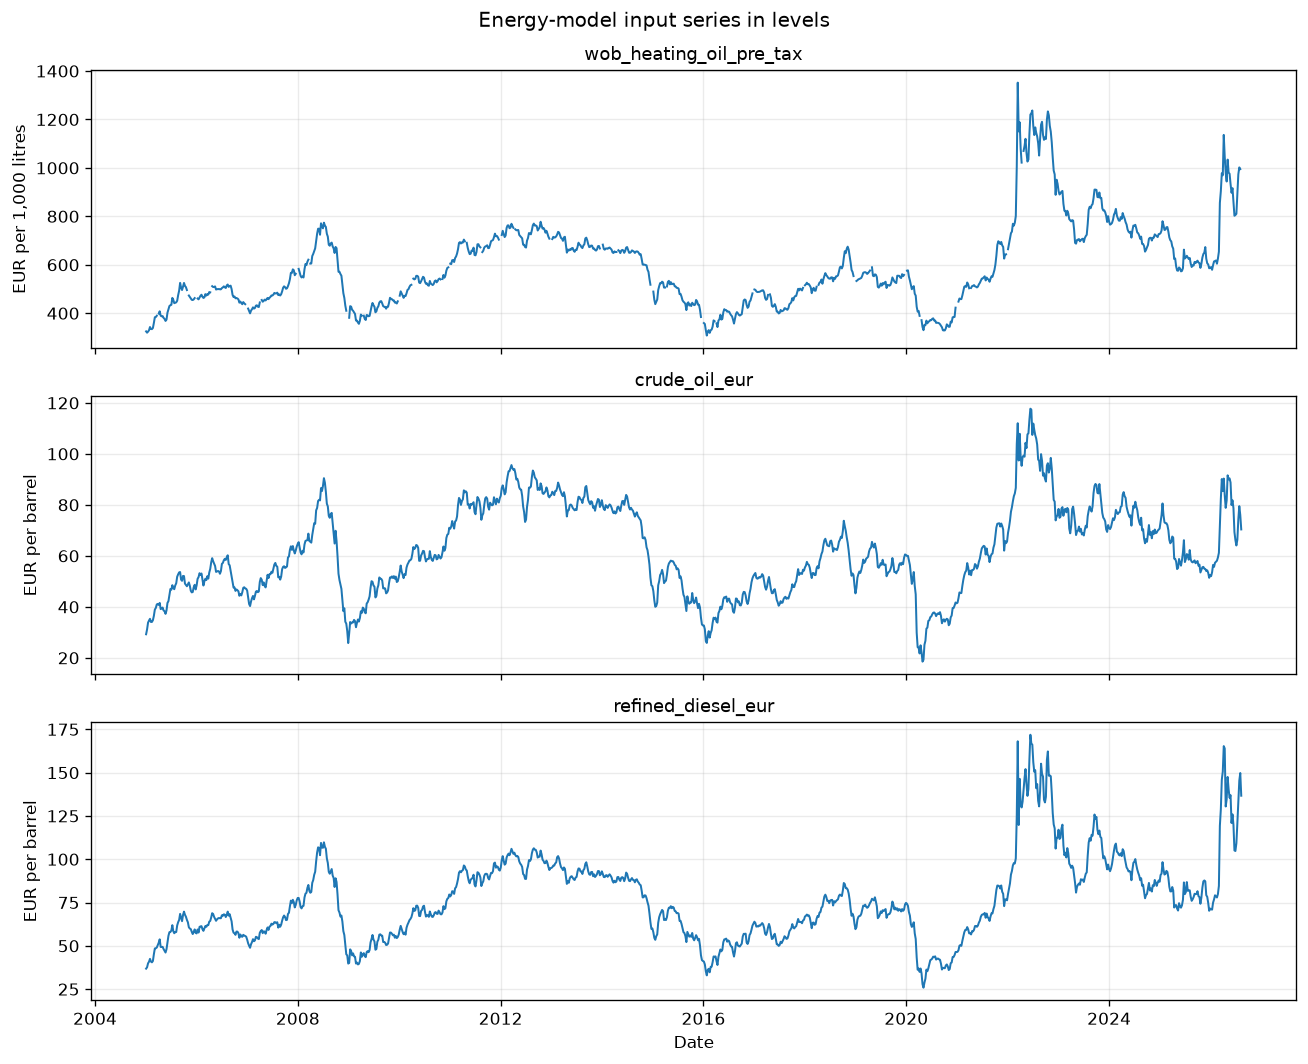

In [2]:
# Set VINTAGE = "YYYYMMDD" to force one processed vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path
        for path in PROCESSED_ROOT.glob(f"*/{SPEC['dataset']}")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No {SPEC['dataset']} found below {PROCESSED_ROOT}."
        )
    COMPONENT_DATASET = candidates[-1]
else:
    COMPONENT_DATASET = PROCESSED_ROOT / VINTAGE / SPEC["dataset"]

levels = load_weekly_fuel_panel(COMPONENT_DATASET, model=MODEL)

print(f"Dataset: {COMPONENT_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")
print(f"Rows: {len(levels):,}; all dates Monday: {(levels.index.dayofweek == 0).all()}")

display(style_numeric_table(
    weekly_fuel_series_construction_table(COMPONENT_DATASET, MODEL),
    caption="Construction of the weekly liquid fuels-model level series",
))
coverage_table = weekly_partial_period_table(COMPONENT_DATASET, MODEL)
if not coverage_table.empty:
    display(style_numeric_table(
        coverage_table,
        caption="Final-period aggregation coverage (builder sidecar)",
    ))

partial_mask = levels.attrs.get("partial_period_mask", pd.DataFrame())
if isinstance(partial_mask, pd.DataFrame) and not partial_mask.empty:
    display(style_numeric_table(
        partial_mask,
        caption="Partial final aggregates masked to NaN before BVAR estimation",
    ))

display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed weekly levels after adapter masking",
))
plot_data_levels(levels, units=UNITS)
plt.show()

The endogenous vector is ordered from the consumer price upstream through the
commodity chain:

$$
y_t=
\begin{bmatrix}
\Delta P_t^{\mathrm{heating\ oil,pre\ tax}}\\
\Delta P_t^{\mathrm{crude}}\\
\Delta P_t^{\mathrm{refined\ diesel}}
\end{bmatrix},
\qquad \Delta x_t=x_t-x_{t-1}.
$$

No log transformation and no seasonal dummy are used in this weekly equation.
The observed-level state equation treats published weeks exactly; missing WOB weeks
inside the estimation sample are latent and are redrawn in each Gibbs iteration.


,value
missing_data_method,linear
missing_treatment_exact,False
interpolated_level_cells,49
frequency,weekly
calendar_rule,W-MON
estimation_mode,balanced sample
companion_warmup_start,2005-01-10 00:00:00
augmentation_anchor,not required
estimation_end,2026-08-03 00:00:00
VAR_regression_observations,1102


,wob_heating_oil_pre_tax,crude_oil_eur,refined_diesel_eur
date,,,
2026-08-10,—,-5.65,-13.10


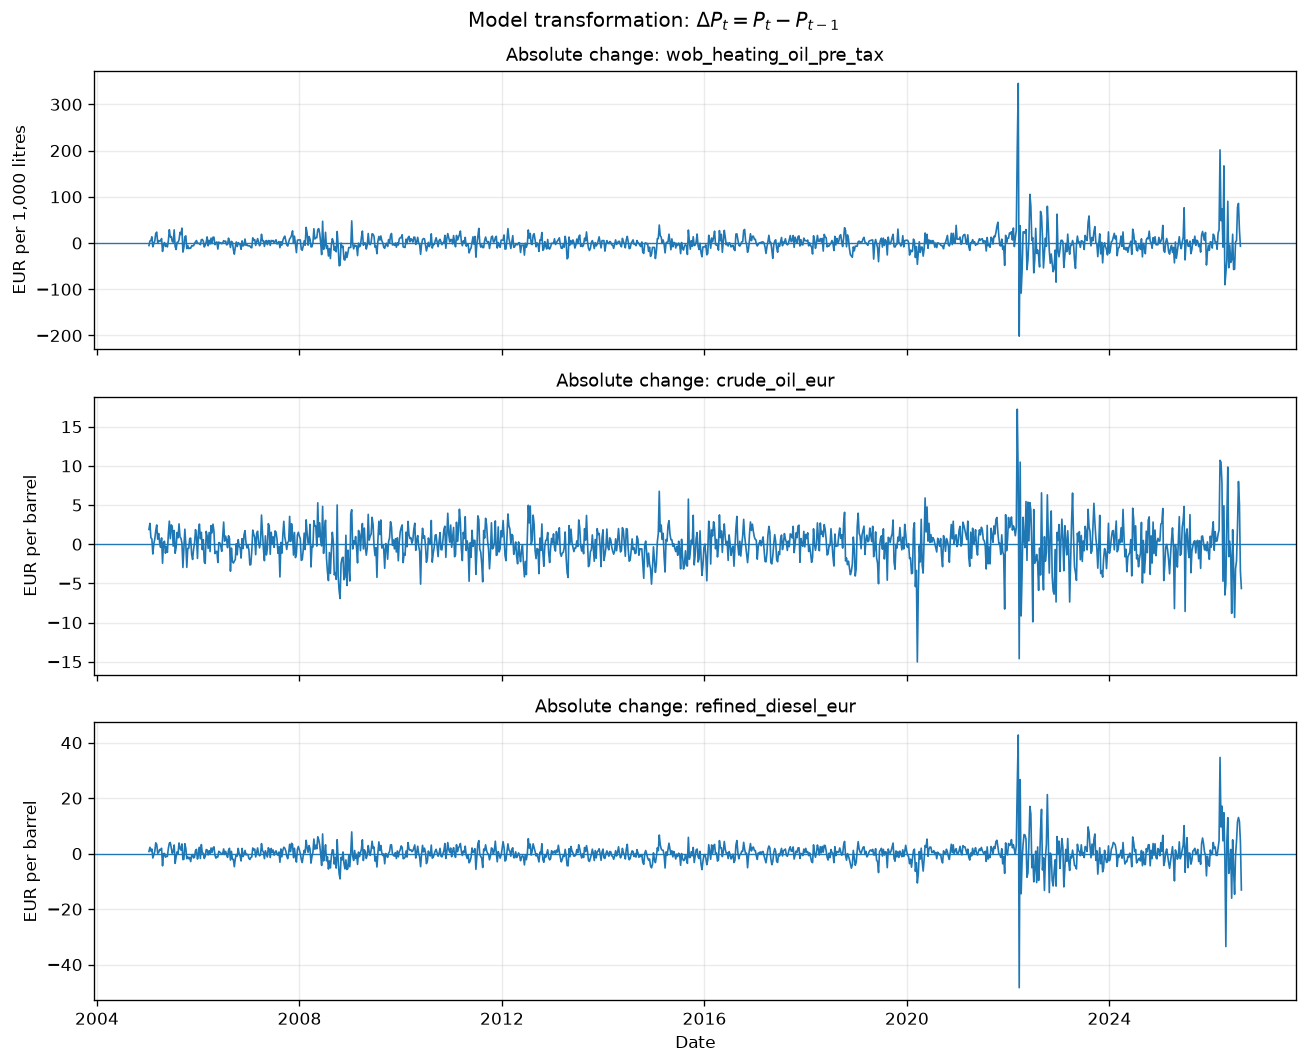

In [3]:
prep = prepare_bvar_panel(
    levels,
    p=P,
    variables=VARIABLES,
    frequency="weekly",
    missing_data_method=MISSING_DATA_METHOD,
)

transformation_summary = pd.Series({
    "missing_data_method": prep["missing_data_method"],
    "missing_treatment_exact": prep["missing_treatment_exact"],
    "interpolated_level_cells": prep["n_interpolated_level_cells"],
    "frequency": prep["frequency"],
    "calendar_rule": prep["calendar_rule"],
    "estimation_mode": (
        "Durbin-Koopman interior data augmentation"
        if prep.get("requires_data_augmentation", False)
        else "balanced sample"
    ),
    "companion_warmup_start": prep["balanced_start"],
    "augmentation_anchor": prep.get("augmentation_anchor", "not required"),
    "estimation_end": prep["balanced_end"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "regression_columns_per_equation": prep["k"],
    "interior_missing_dates": prep.get("n_interior_missing_dates", 0),
    "interior_missing_level_cells": prep.get("n_interior_missing_level_cells", 0),
    "ragged_edge_weeks": prep["n_ragged_periods"],
    "latest_calendar_week": prep["last_calendar_date"],
})
display(style_numeric_table(
    transformation_summary.to_frame("value"),
    caption="Transformation and estimation sample",
))

if prep.get("requires_data_augmentation", False):
    missing_dates = pd.DataFrame({
        "date": prep["interior_missing_dates"],
    }).set_index("date")
    display(style_numeric_table(
        missing_dates,
        caption="Interior weeks entering the Gibbs sampler as latent states",
    ))

display(style_numeric_table(
    prep["ragged"],
    caption="Ragged-edge absolute weekly changes",
))

if prep.get("n_interpolated_level_cells", 0):
    linear_imputation = (
        prep["levels"]
        .where(prep["interpolated_level_mask"])
        .stack()
        .rename("linear_imputation")
        .to_frame()
    )
    linear_imputation.index.names = ["date", "variable"]
    display(style_numeric_table(
        linear_imputation.head(30),
        caption="Linear interpolation audit — first imputed interior levels",
    ))

plot_absolute_differences(prep["differences"], units=UNITS)
plt.show()

## 3. Priors


,value,interpretation
lambda1,0.20,overall Minnesota lag tightness
lambda2,0.50,additional cross-lag tightness
lambda3,1.00,lag-decay exponent
lambda4,10.00,constant prior scale
A prior variance,10.00,variance of each free contemporaneous A coefficient
phi prior mean,0.02,prior mean of volatility-of-volatility variance
outlier alpha,2.50,Beta outlier pseudo-count
outlier beta,117.50,Beta regular-observation pseudo-count


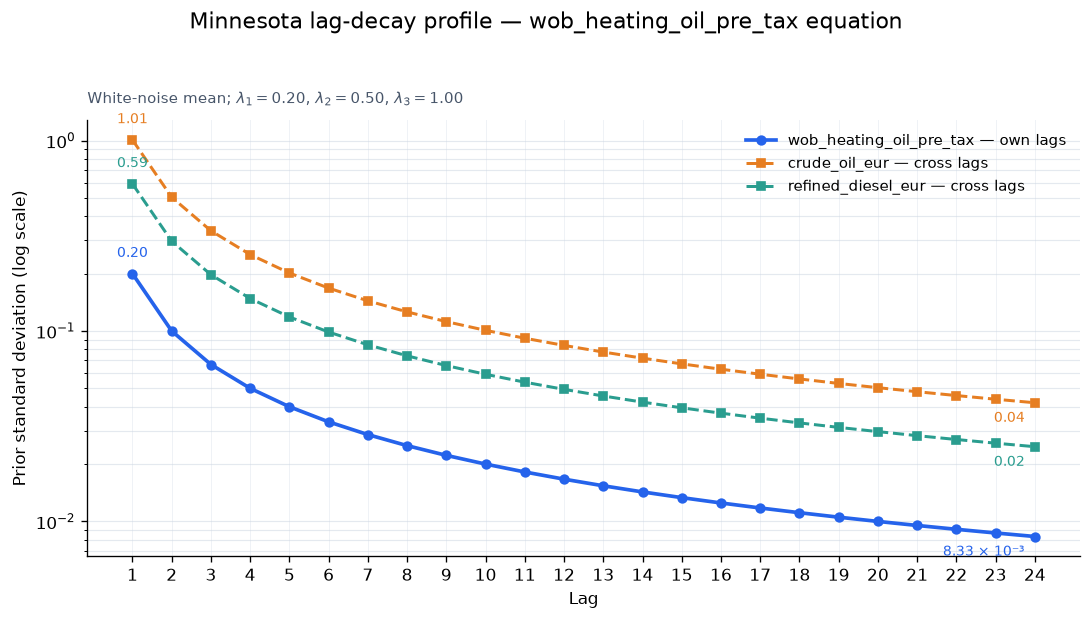

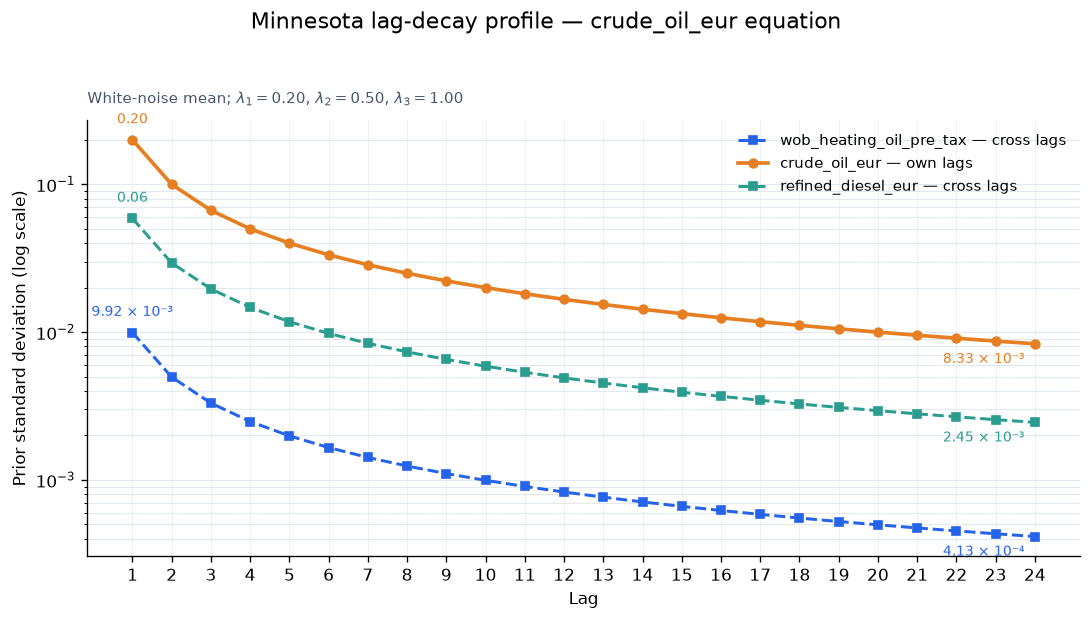

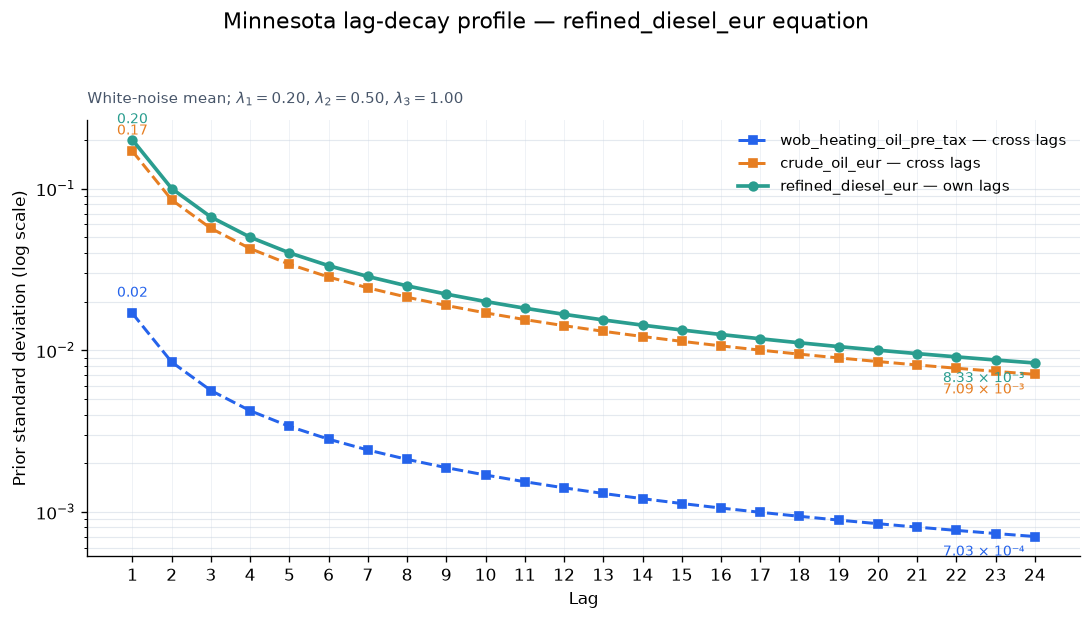

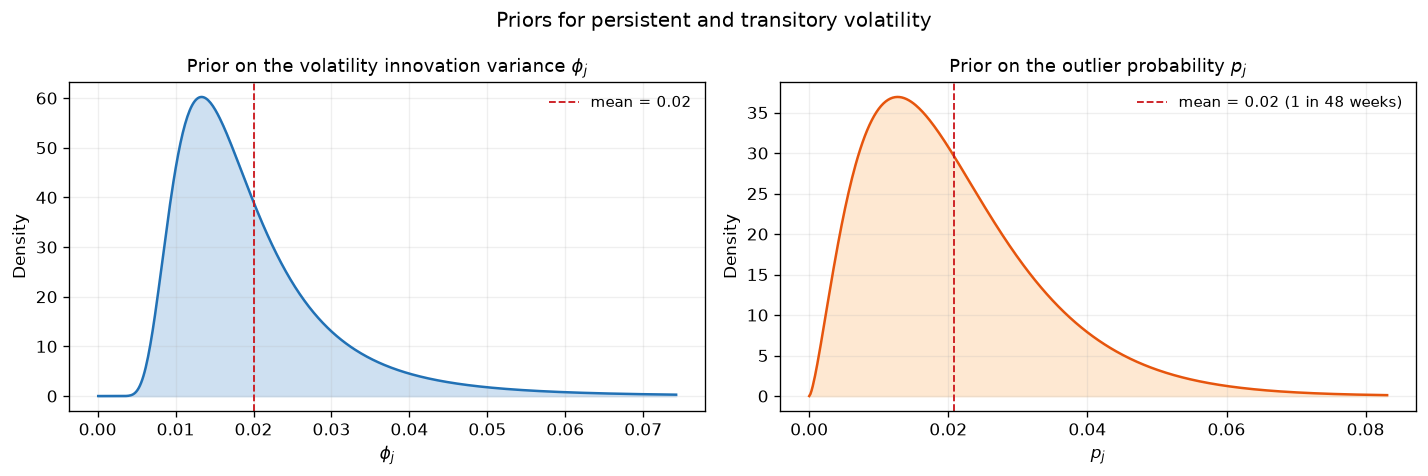

In [4]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(prep, prior_config)

prior_table = pd.DataFrame({
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
    ],
    "interpretation": [
        "overall Minnesota lag tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
        "variance of each free contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta outlier pseudo-count",
        "Beta regular-observation pseudo-count",
    ],
}, index=[
    "lambda1", "lambda2", "lambda3", "lambda4",
    "A prior variance", "phi prior mean",
    "outlier alpha", "outlier beta",
])
display(style_numeric_table(prior_table, caption="Prior hyperparameters"))

prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)
plot_phi_and_outlier_priors(prior)
plt.show()

## 4. Posterior and Gibbs sampler


In [5]:
sampler_config = SamplerConfig(
    reps=6_000,
    burn=3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=500,
    dk_projection_mode="strict",
    dk_level_relative_gate=1e-6,
    dk_difference_relative_gate=1e-6,
)

result = run_energy_bvar(
    levels=levels,
    model_id=COMPONENT,
    vintage=COMPONENT_DATASET.parent.name,
    p=P,
    variables=VARIABLES,
    frequency="weekly",
    prior_config=prior_config,
    sampler_config=sampler_config,
    missing_data_method=MISSING_DATA_METHOD,
    code_version=CODE_VERSION,
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"Run ID: {result['metadata']['run_id']}")
print(f"Missing-data method: {result['metadata']['missing_data_method']}")
print(f"Exact missing-data treatment: {result['metadata']['missing_treatment_exact']}")
print(f"Interpolated level cells: {result['metadata']['interpolated_level_cells']}")
print(f"Frequency: {result['metadata']['frequency']}")
print(f"Data augmentation: {result['metadata'].get('data_augmentation', 'none')}")
print(
    "B instability proposal rejection rate: "
    f"{result['B_instability_rejection_rate']:.2%}"
)
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

dk_diag = result.get("dk_projection_diagnostics", {})
if dk_diag:
    print(
        "DK projection max relative errors: "
        f"level={dk_diag.get('level_error', {}).get('max', np.nan):.3e}, "
        f"difference={dk_diag.get('difference_adjustment', {}).get('max', np.nan):.3e}"
    )

if SAVE_RESULTS:
    saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
    print(f"Saved run: {saved_result_paths['directory']}")

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8801
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8765
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.8688
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8857
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.8873
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.8881
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.8693
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8858
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.8778
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.8761
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.8785
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.8617
Retained posterior draws: 3,000
Run ID: ef7625d8797235b448bb1da7f0db677cb016a0a326f4275086f8d3ef745042f8
Missing-data method: linear
Exact missing-data treatment:

,KSC offset
wob_heating_oil_pre_tax,7.21 × 10⁻⁵
crude_oil_eur,1.67 × 10⁻⁶
refined_diesel_eur,2.38 × 10⁻⁶


## 5. Posterior results



wob_heating_oil_pre_tax equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,244.28,0.22,0.23,0.33,-0.33,-0.11,0.55,0.76,1736.28
wob_heating_oil_pre_tax L1,0.00,0.20,-0.11,-0.11,0.05,-0.19,-0.16,-0.07,-0.04,1622.04
crude_oil_eur L1,0.00,1.01,1.21,1.21,0.30,0.74,0.92,1.51,1.70,1352.21
refined_diesel_eur L1,0.00,0.59,1.24,1.24,0.28,0.78,0.96,1.51,1.69,1487.57
wob_heating_oil_pre_tax L2,0.00,0.10,-0.05,-0.05,0.03,-0.10,-0.08,-0.01,5.13 × 10⁻³,1486.70
crude_oil_eur L2,0.00,0.50,-0.21,-0.20,0.23,-0.59,-0.44,0.02,0.16,1582.77
refined_diesel_eur L2,0.00,0.30,0.41,0.41,0.19,0.10,0.22,0.60,0.72,2521.27
wob_heating_oil_pre_tax L3,0.00,0.07,-0.02,-0.02,0.03,-0.06,-0.05,0.01,0.03,2099.87
crude_oil_eur L3,0.00,0.34,-0.07,-0.07,0.19,-0.38,-0.26,0.12,0.23,2053.88


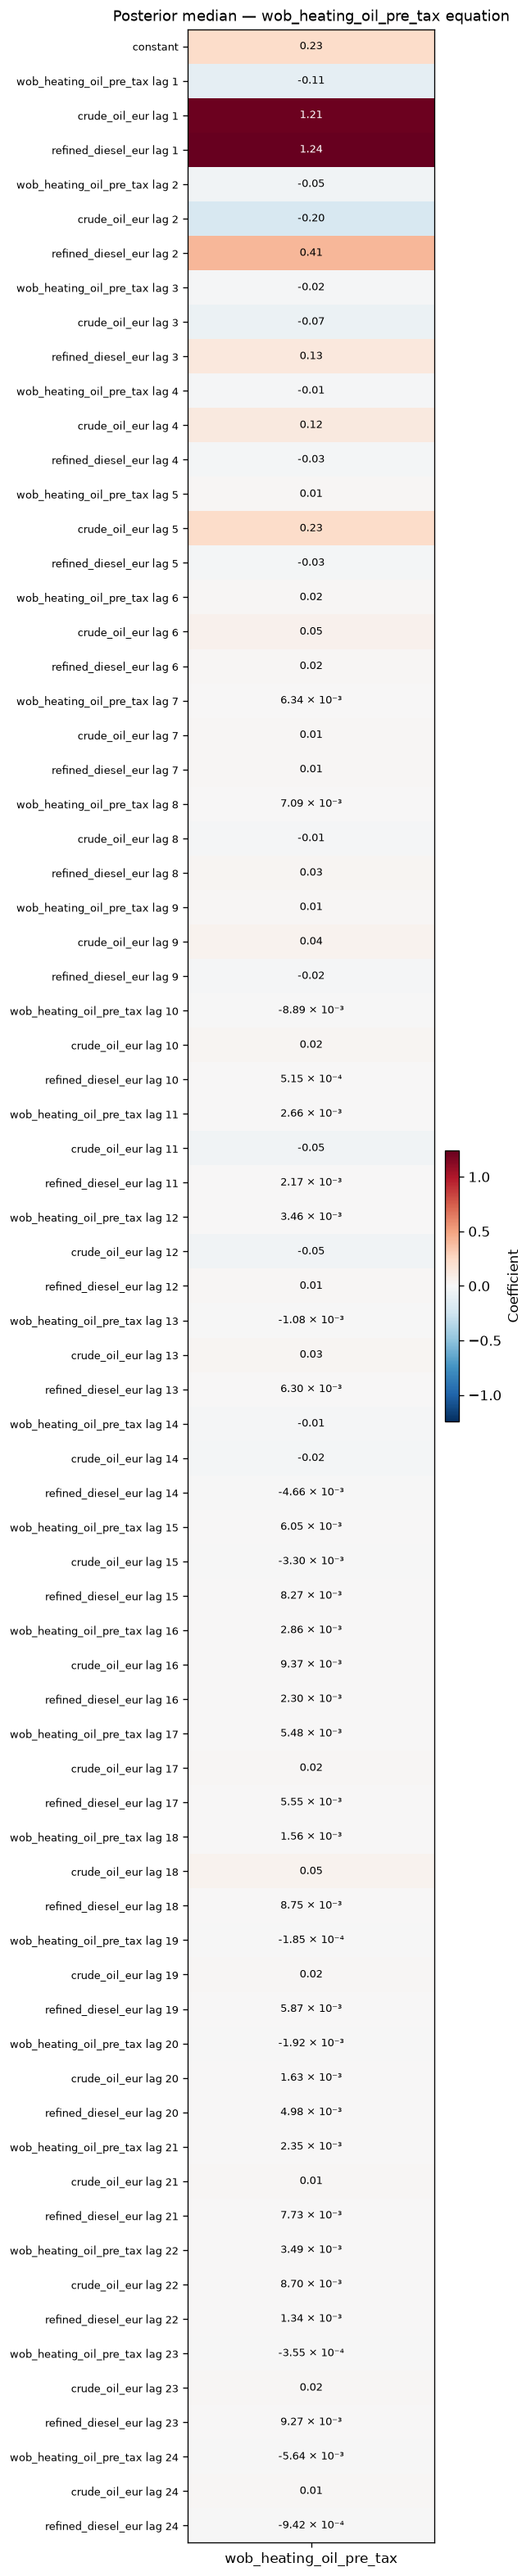

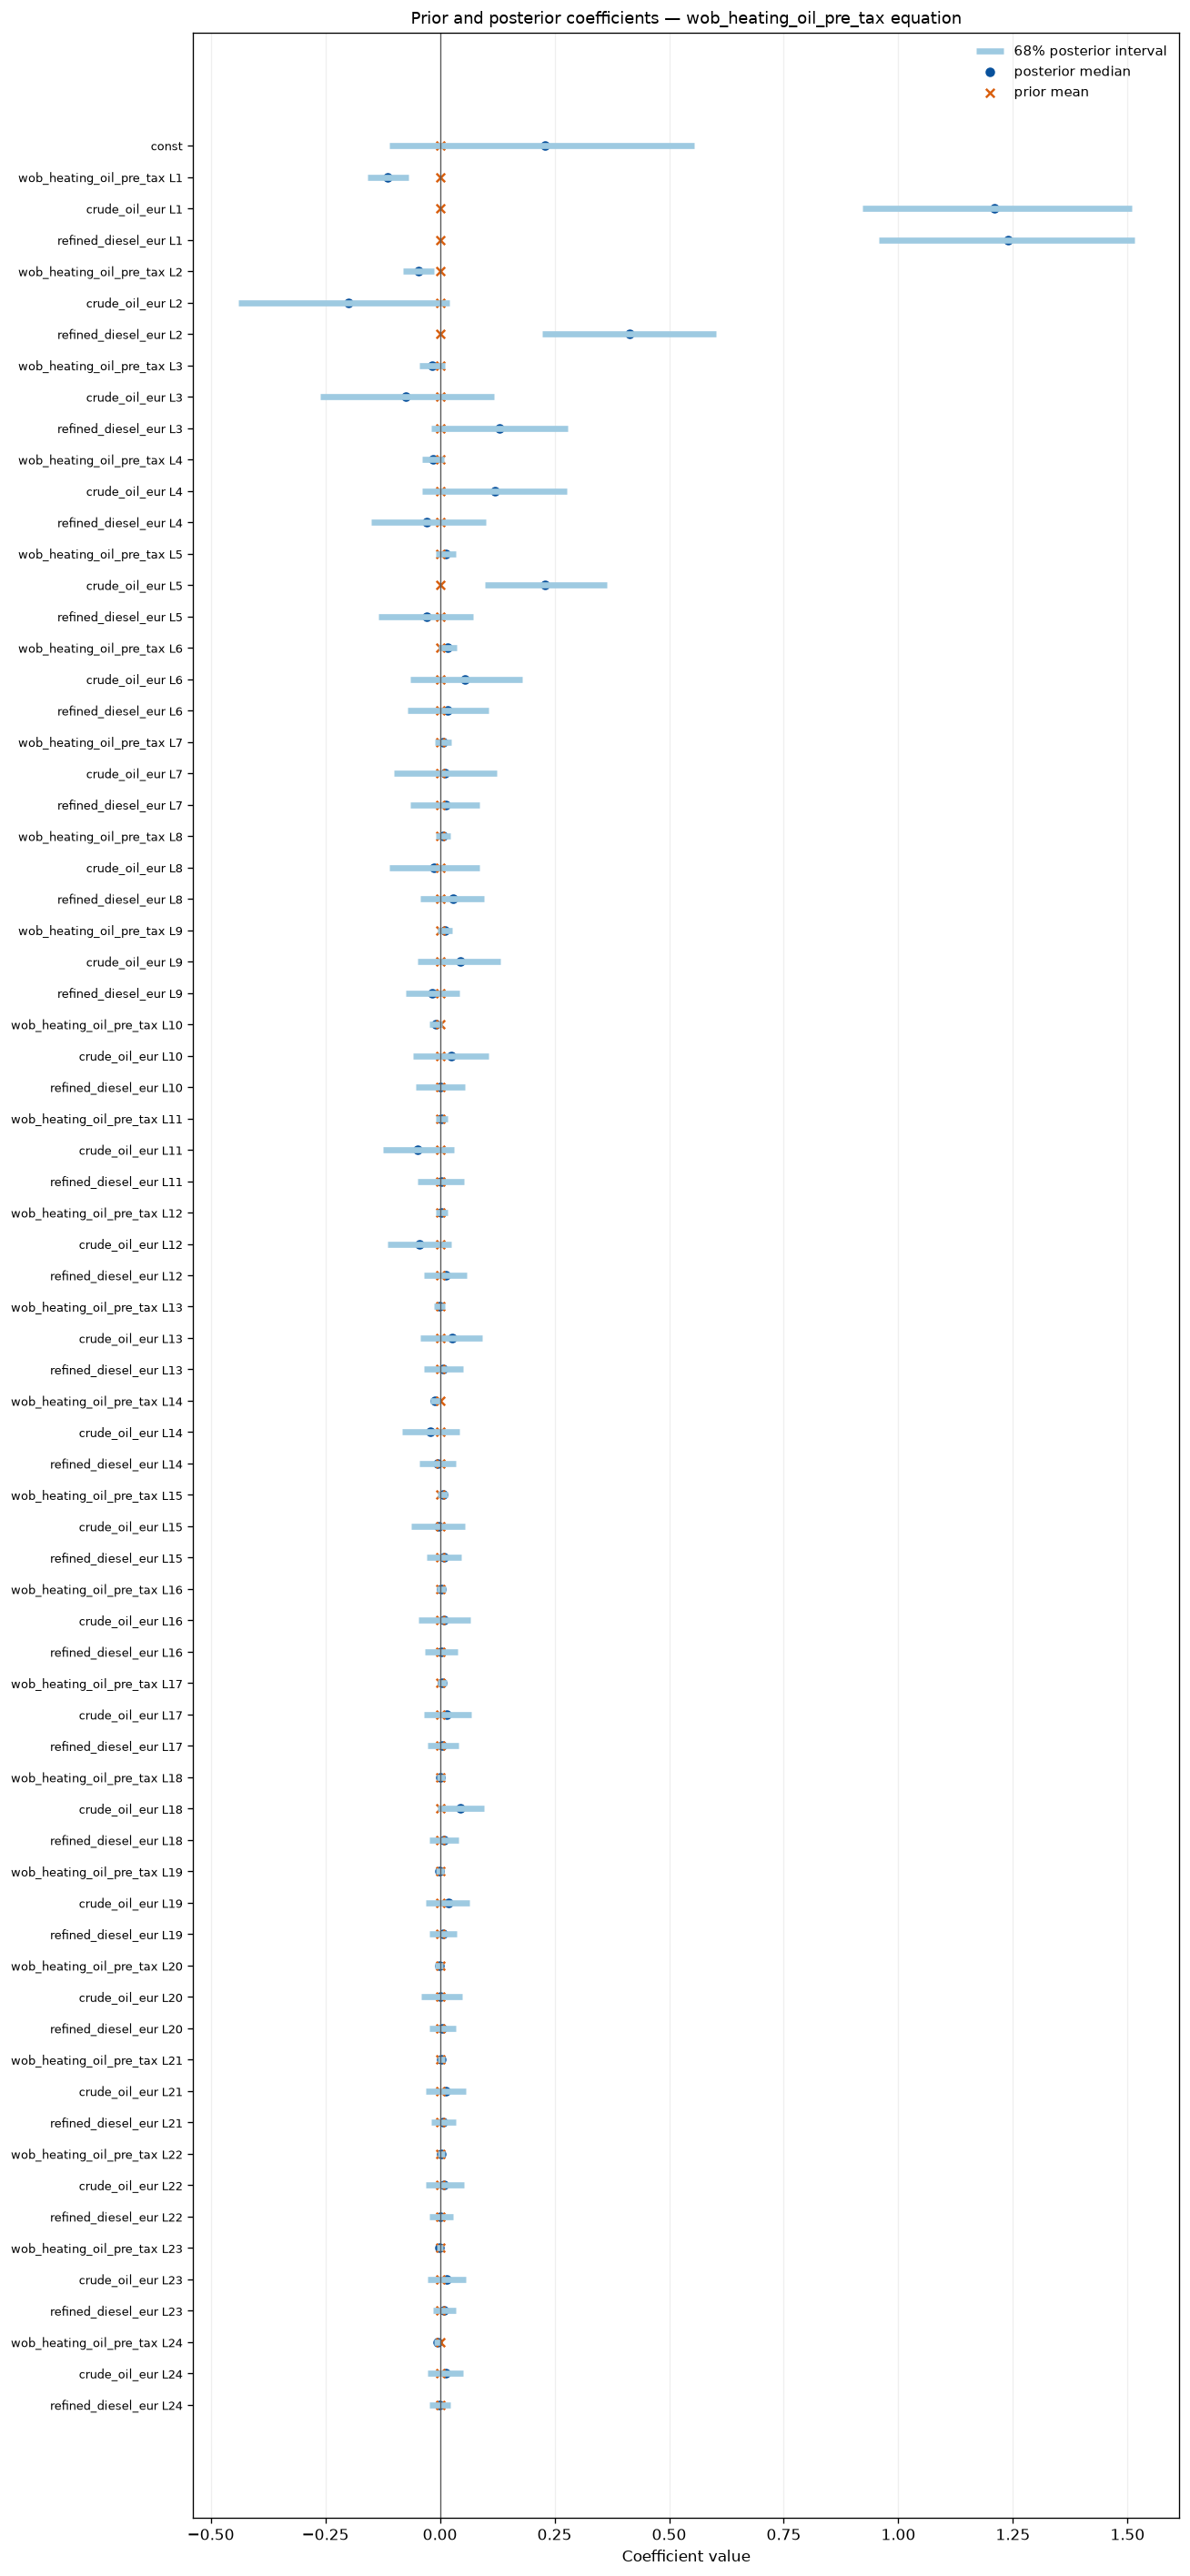


crude_oil_eur equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,24.24,0.06,0.06,0.05,-0.02,0.01,0.12,0.15,1944.31
wob_heating_oil_pre_tax L1,0.00,9.92 × 10⁻³,-2.36 × 10⁻³,-2.44 × 10⁻³,5.71 × 10⁻³,-0.01,-7.95 × 10⁻³,3.39 × 10⁻³,7.27 × 10⁻³,1659.37
crude_oil_eur L1,0.00,0.20,0.24,0.24,0.05,0.17,0.20,0.29,0.31,1839.43
refined_diesel_eur L1,0.00,0.06,-0.02,-0.02,0.04,-0.08,-0.05,0.02,0.04,2105.61
wob_heating_oil_pre_tax L2,0.00,4.96 × 10⁻³,9.74 × 10⁻⁴,9.84 × 10⁻⁴,3.71 × 10⁻³,-5.05 × 10⁻³,-2.78 × 10⁻³,4.55 × 10⁻³,7.00 × 10⁻³,2263.97
crude_oil_eur L2,0.00,0.10,-0.03,-0.03,0.03,-0.09,-0.06,6.98 × 10⁻³,0.03,2179.80
refined_diesel_eur L2,0.00,0.03,1.72 × 10⁻³,1.72 × 10⁻³,0.02,-0.04,-0.02,0.02,0.04,2590.34
wob_heating_oil_pre_tax L3,0.00,3.31 × 10⁻³,1.11 × 10⁻³,1.14 × 10⁻³,2.74 × 10⁻³,-3.31 × 10⁻³,-1.64 × 10⁻³,3.78 × 10⁻³,5.63 × 10⁻³,2599.44
crude_oil_eur L3,0.00,0.07,-0.02,-0.02,0.03,-0.06,-0.05,9.54 × 10⁻³,0.03,2296.61


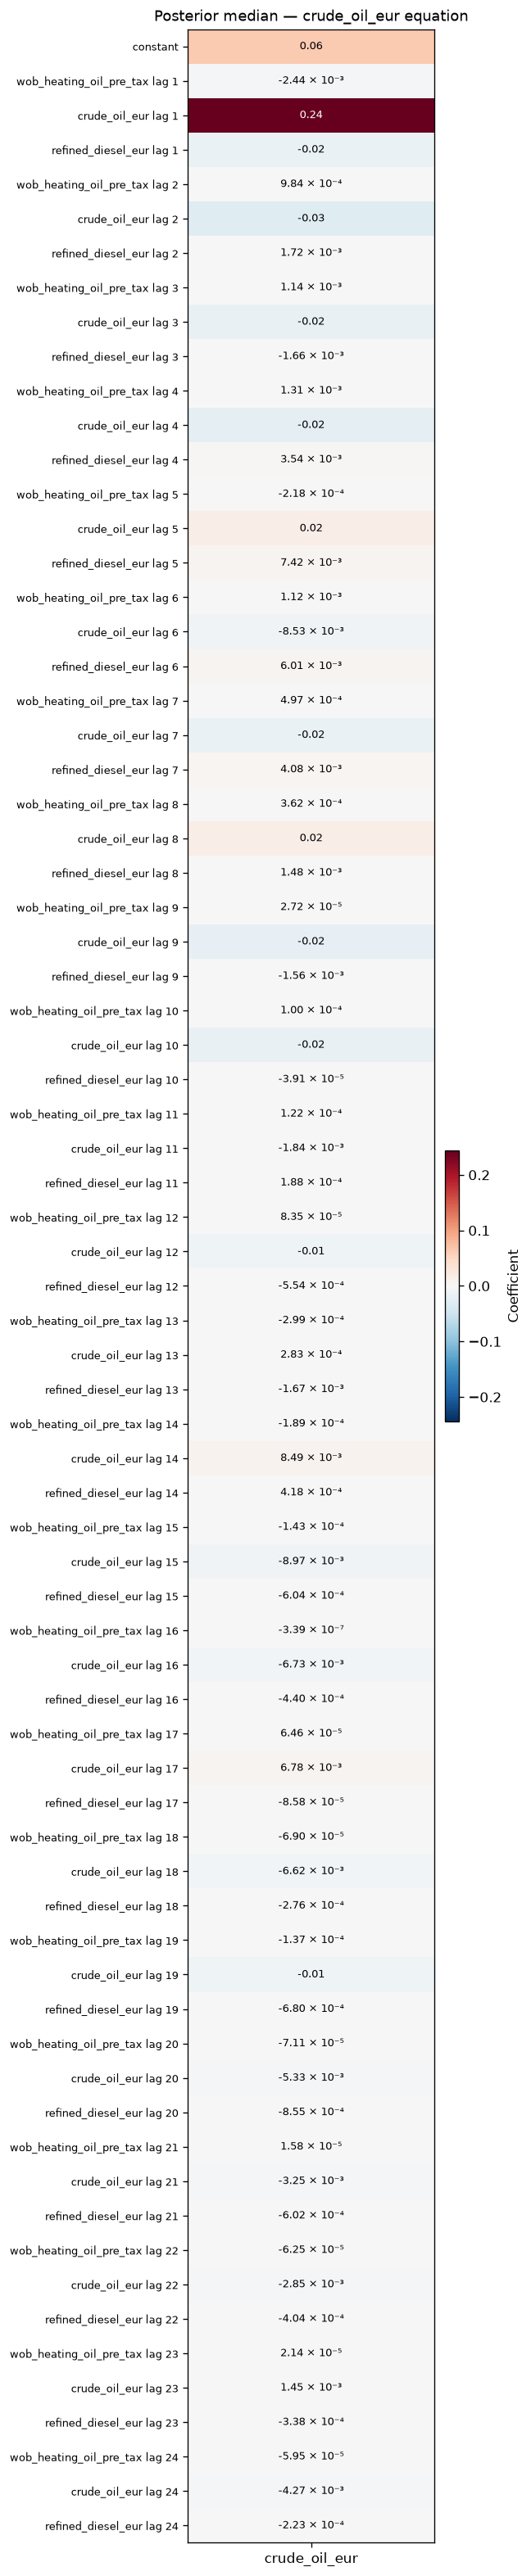

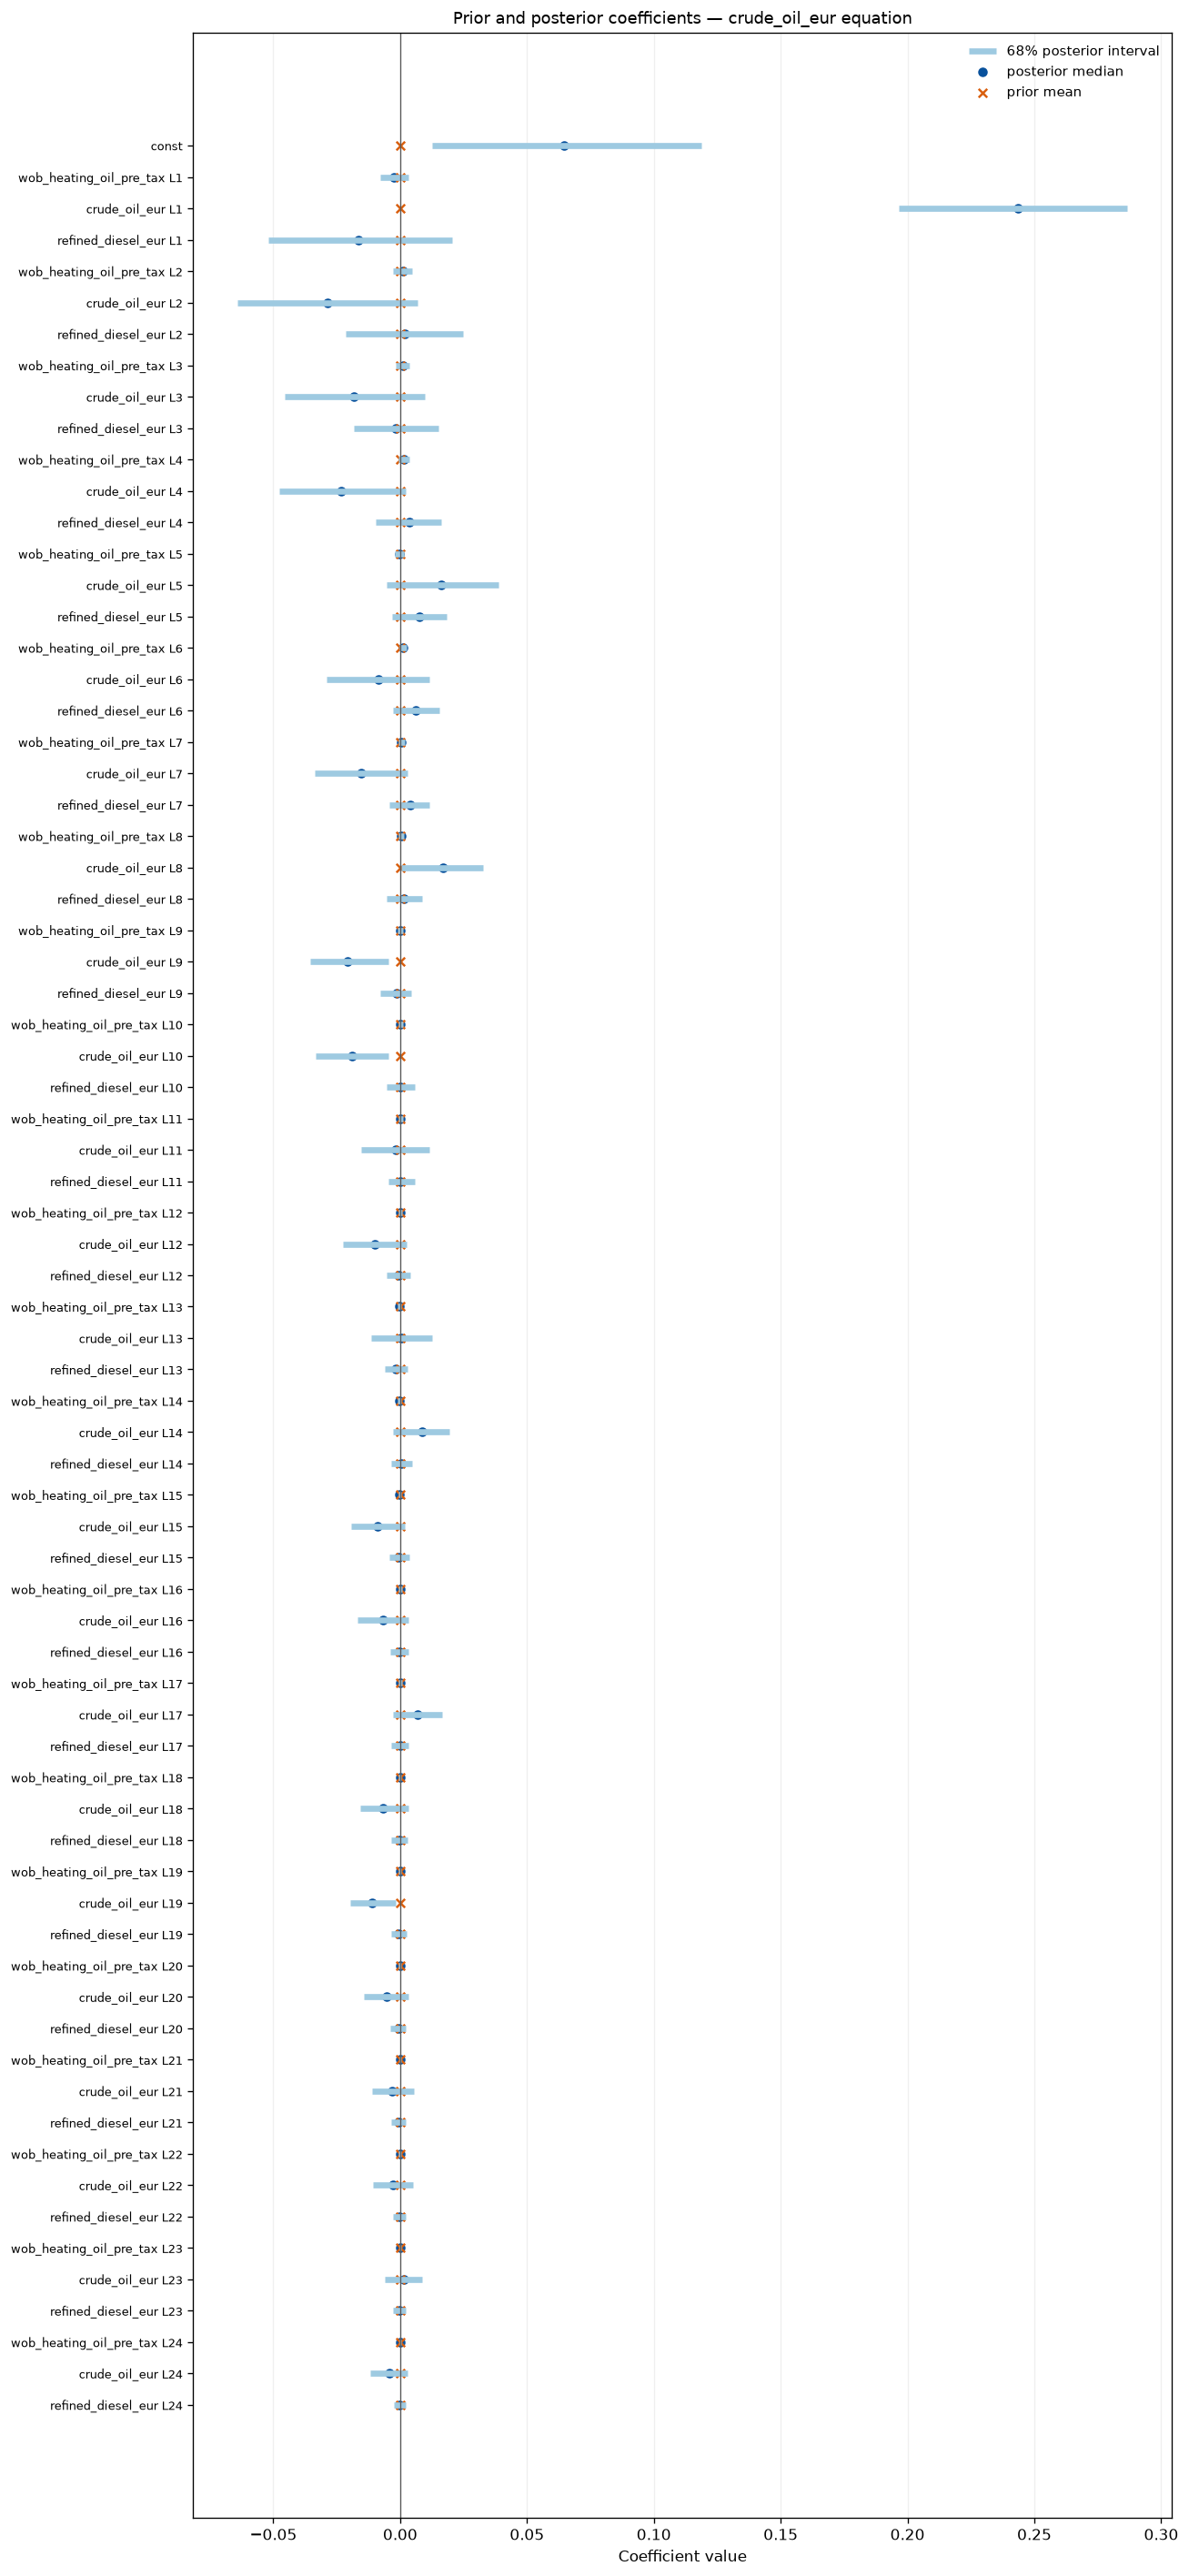


refined_diesel_eur equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,41.24,0.06,0.06,0.06,-0.04,-3.21 × 10⁻³,0.12,0.16,1777.49
wob_heating_oil_pre_tax L1,0.00,0.02,3.81 × 10⁻³,3.81 × 10⁻³,7.37 × 10⁻³,-8.26 × 10⁻³,-3.45 × 10⁻³,0.01,0.02,1491.71
crude_oil_eur L1,0.00,0.17,0.26,0.25,0.05,0.17,0.20,0.31,0.34,1393.87
refined_diesel_eur L1,0.00,0.20,9.46 × 10⁻³,9.63 × 10⁻³,0.05,-0.07,-0.04,0.06,0.09,1422.28
wob_heating_oil_pre_tax L2,0.00,8.44 × 10⁻³,4.21 × 10⁻³,4.20 × 10⁻³,5.13 × 10⁻³,-4.11 × 10⁻³,-8.02 × 10⁻⁴,9.17 × 10⁻³,0.01,1752.20
crude_oil_eur L2,0.00,0.09,-0.02,-0.02,0.04,-0.09,-0.06,0.02,0.04,1938.33
refined_diesel_eur L2,0.00,0.10,-0.05,-0.05,0.03,-0.11,-0.09,-0.02,6.85 × 10⁻³,2259.70
wob_heating_oil_pre_tax L3,0.00,5.63 × 10⁻³,9.79 × 10⁻⁴,1.06 × 10⁻³,3.96 × 10⁻³,-5.43 × 10⁻³,-2.99 × 10⁻³,4.96 × 10⁻³,7.36 × 10⁻³,2276.87
crude_oil_eur L3,0.00,0.06,0.04,0.04,0.03,-0.01,9.95 × 10⁻³,0.07,0.09,1918.53


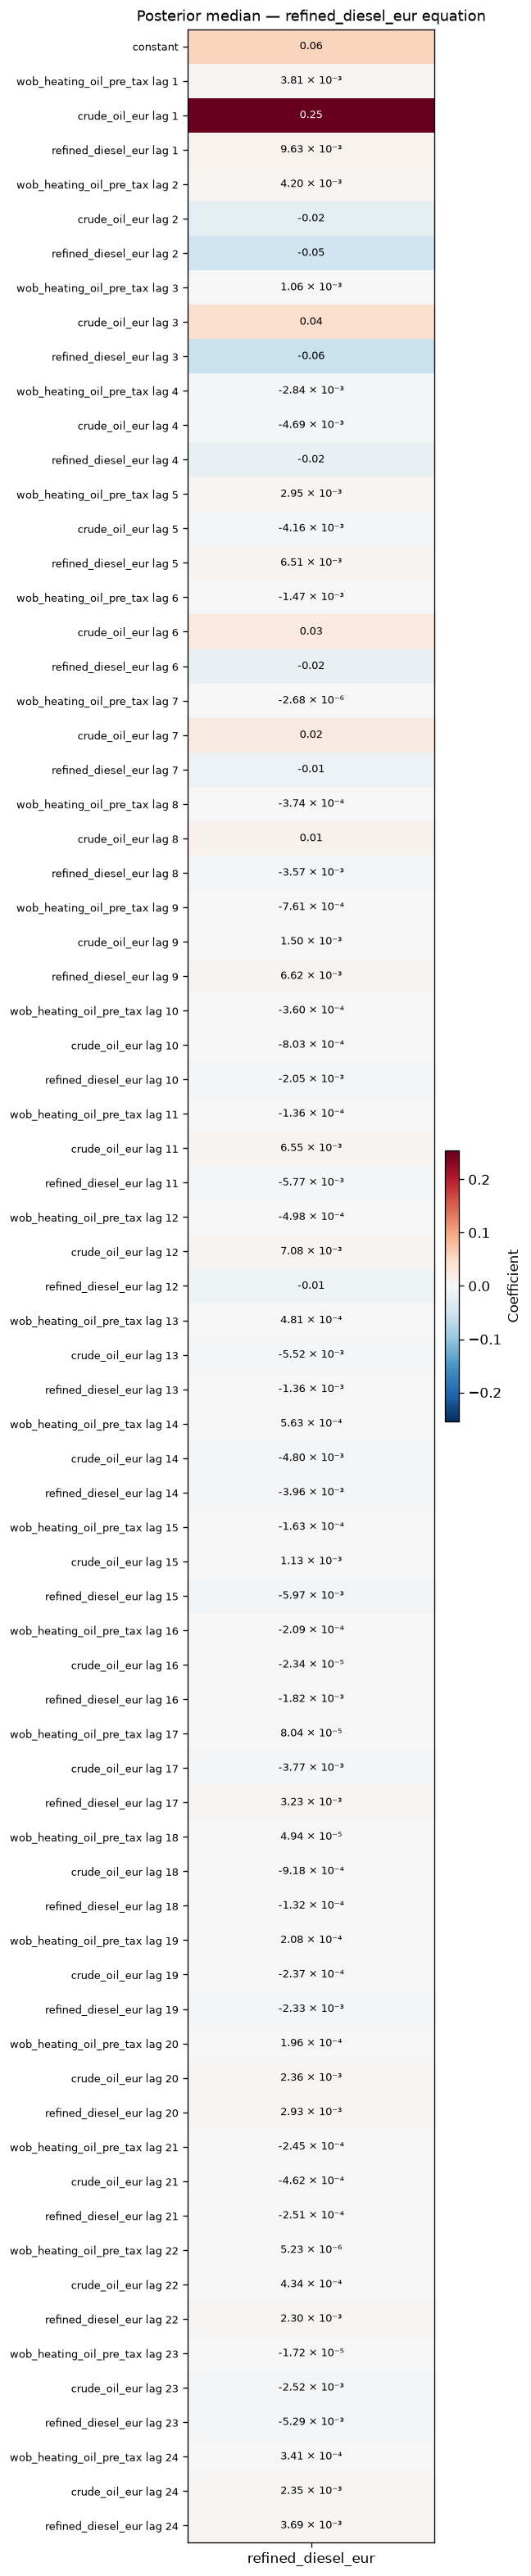

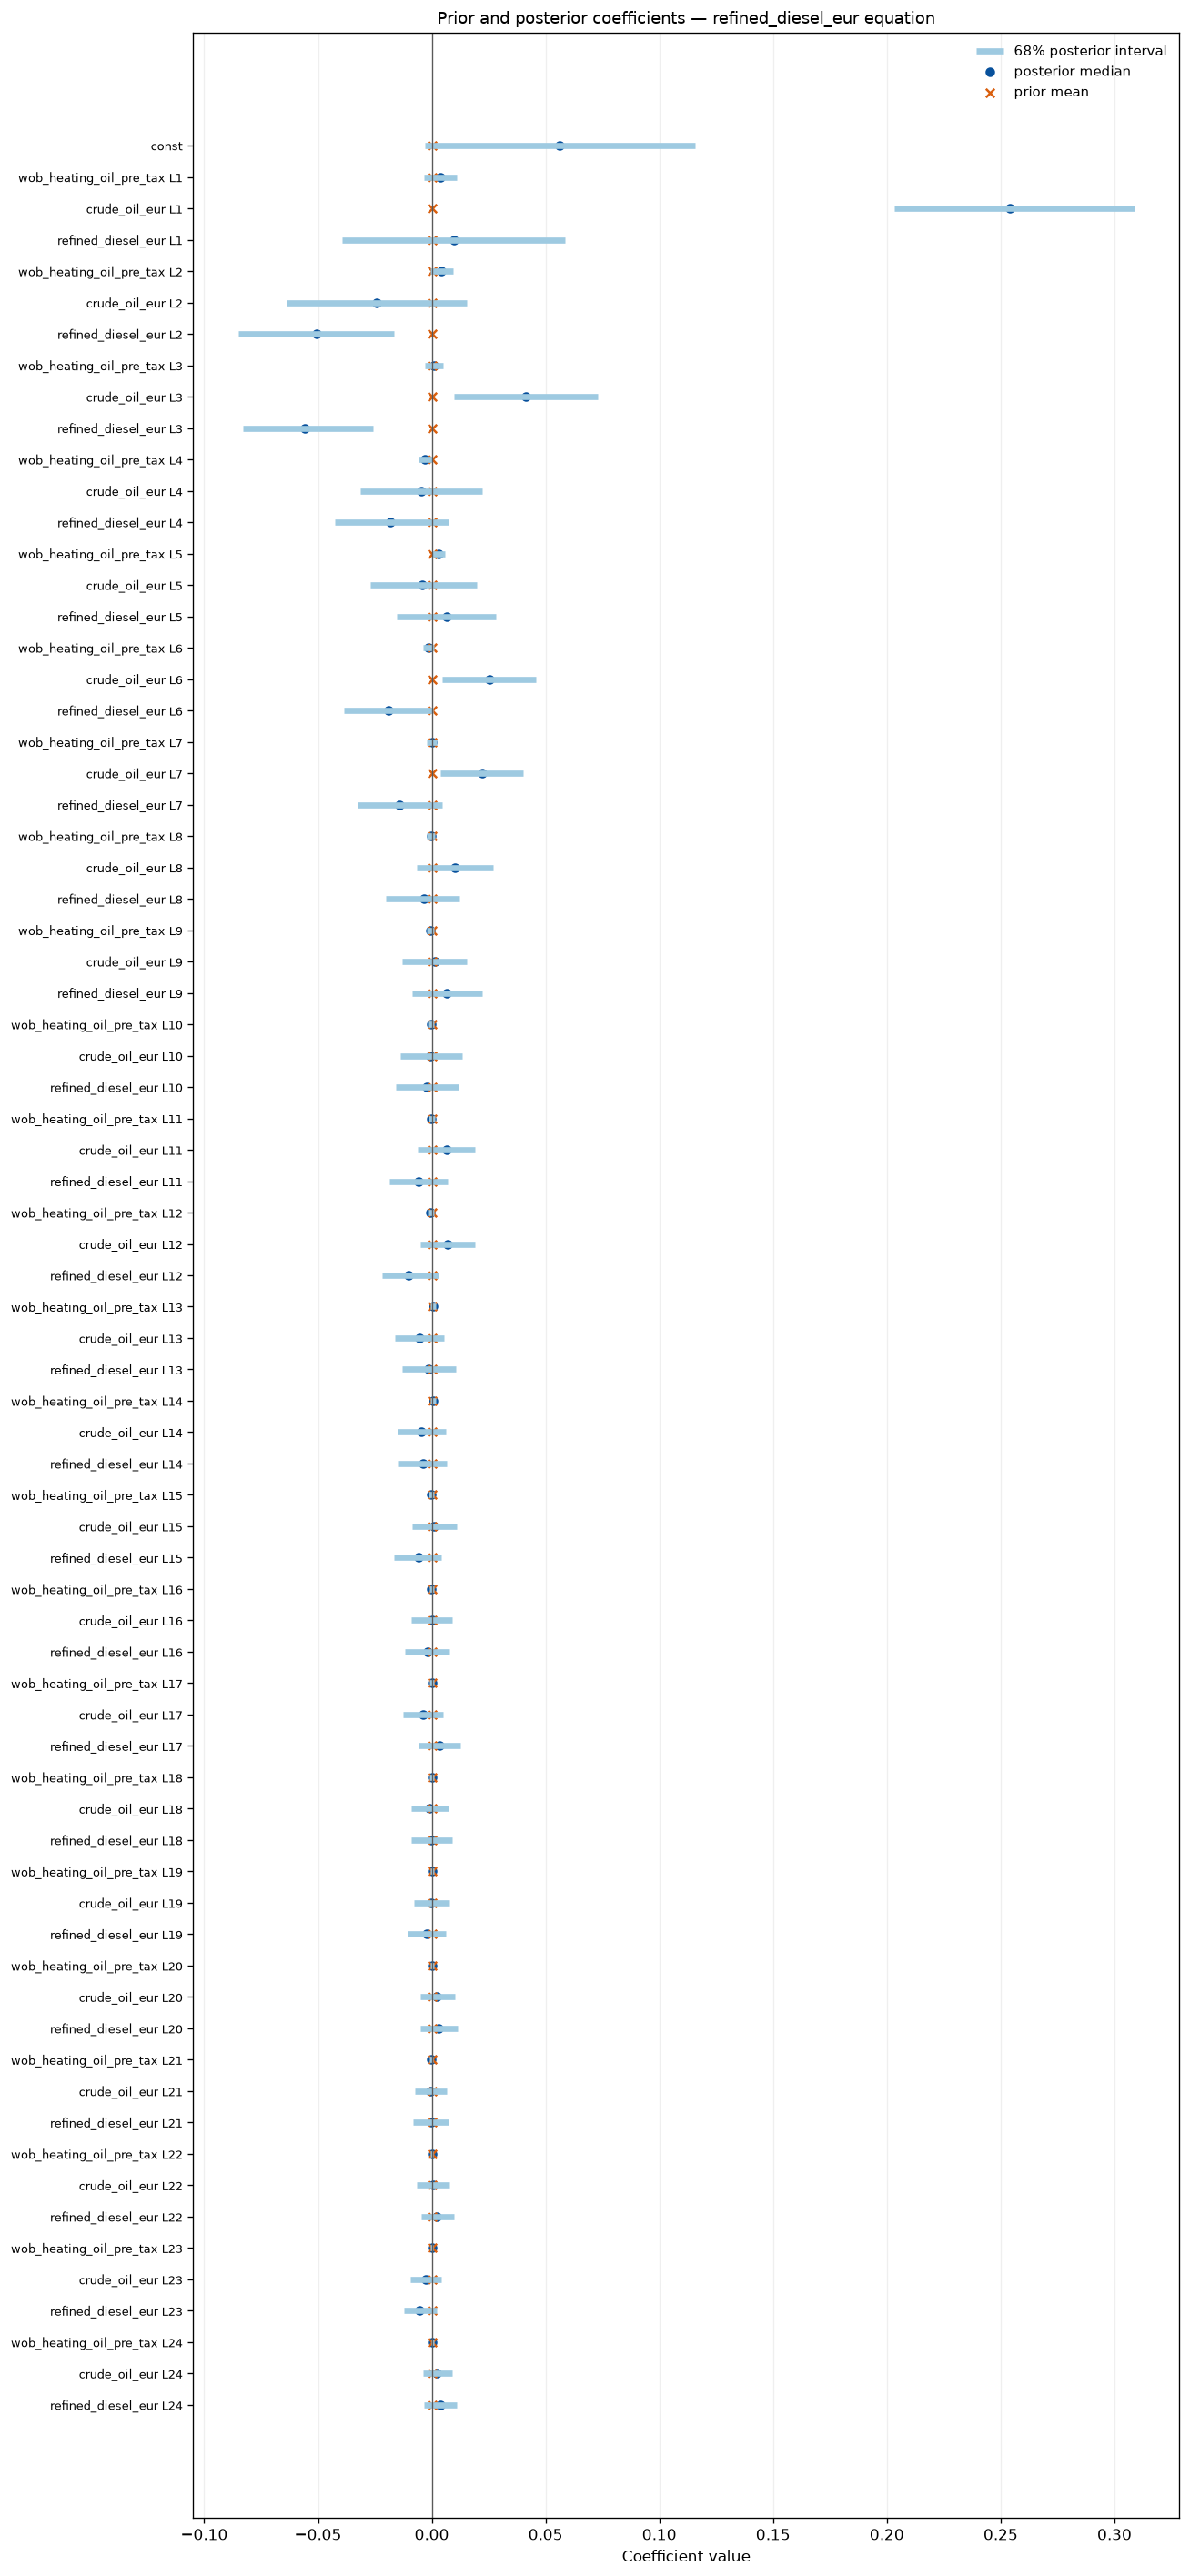

In [6]:
coefficient_tables = coefficient_posterior_tables(result)
for equation in VARIABLES:
    print()
    print(f"{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,-7608.96,19.67,145.82,1.63,0.08
spectral radius,0.88,8.11 × 10⁻³,2974.50,1.49 × 10⁻⁴,0.02
"A[crude_oil_eur,wob_heating_oil_pre_tax]",-0.12,3.52 × 10⁻³,574.43,1.47 × 10⁻⁴,0.04
phi[wob_heating_oil_pre_tax],0.05,0.01,20.89,2.93 × 10⁻³,0.22
p_outlier[wob_heating_oil_pre_tax],5.65 × 10⁻³,3.33 × 10⁻³,113.55,3.13 × 10⁻⁴,0.09
own L1[wob_heating_oil_pre_tax],-0.11,0.05,1622.04,1.12 × 10⁻³,0.02
phi[crude_oil_eur],0.02,5.53 × 10⁻³,71.84,6.52 × 10⁻⁴,0.12
p_outlier[crude_oil_eur],6.24 × 10⁻³,3.03 × 10⁻³,899.95,1.01 × 10⁻⁴,0.03
own L1[crude_oil_eur],0.24,0.05,1839.43,1.05 × 10⁻³,0.02
phi[refined_diesel_eur],0.05,0.01,39.13,2.36 × 10⁻³,0.16


,value
retained_draws,3000.00
median_spectral_radius,0.88
q95_spectral_radius,0.89
maximum_spectral_radius,0.91
retained_unstable_share,0.00
B_total_proposals,6000.00
B_unstable_proposals,0.00
B_instability_rejection_rate,0.00


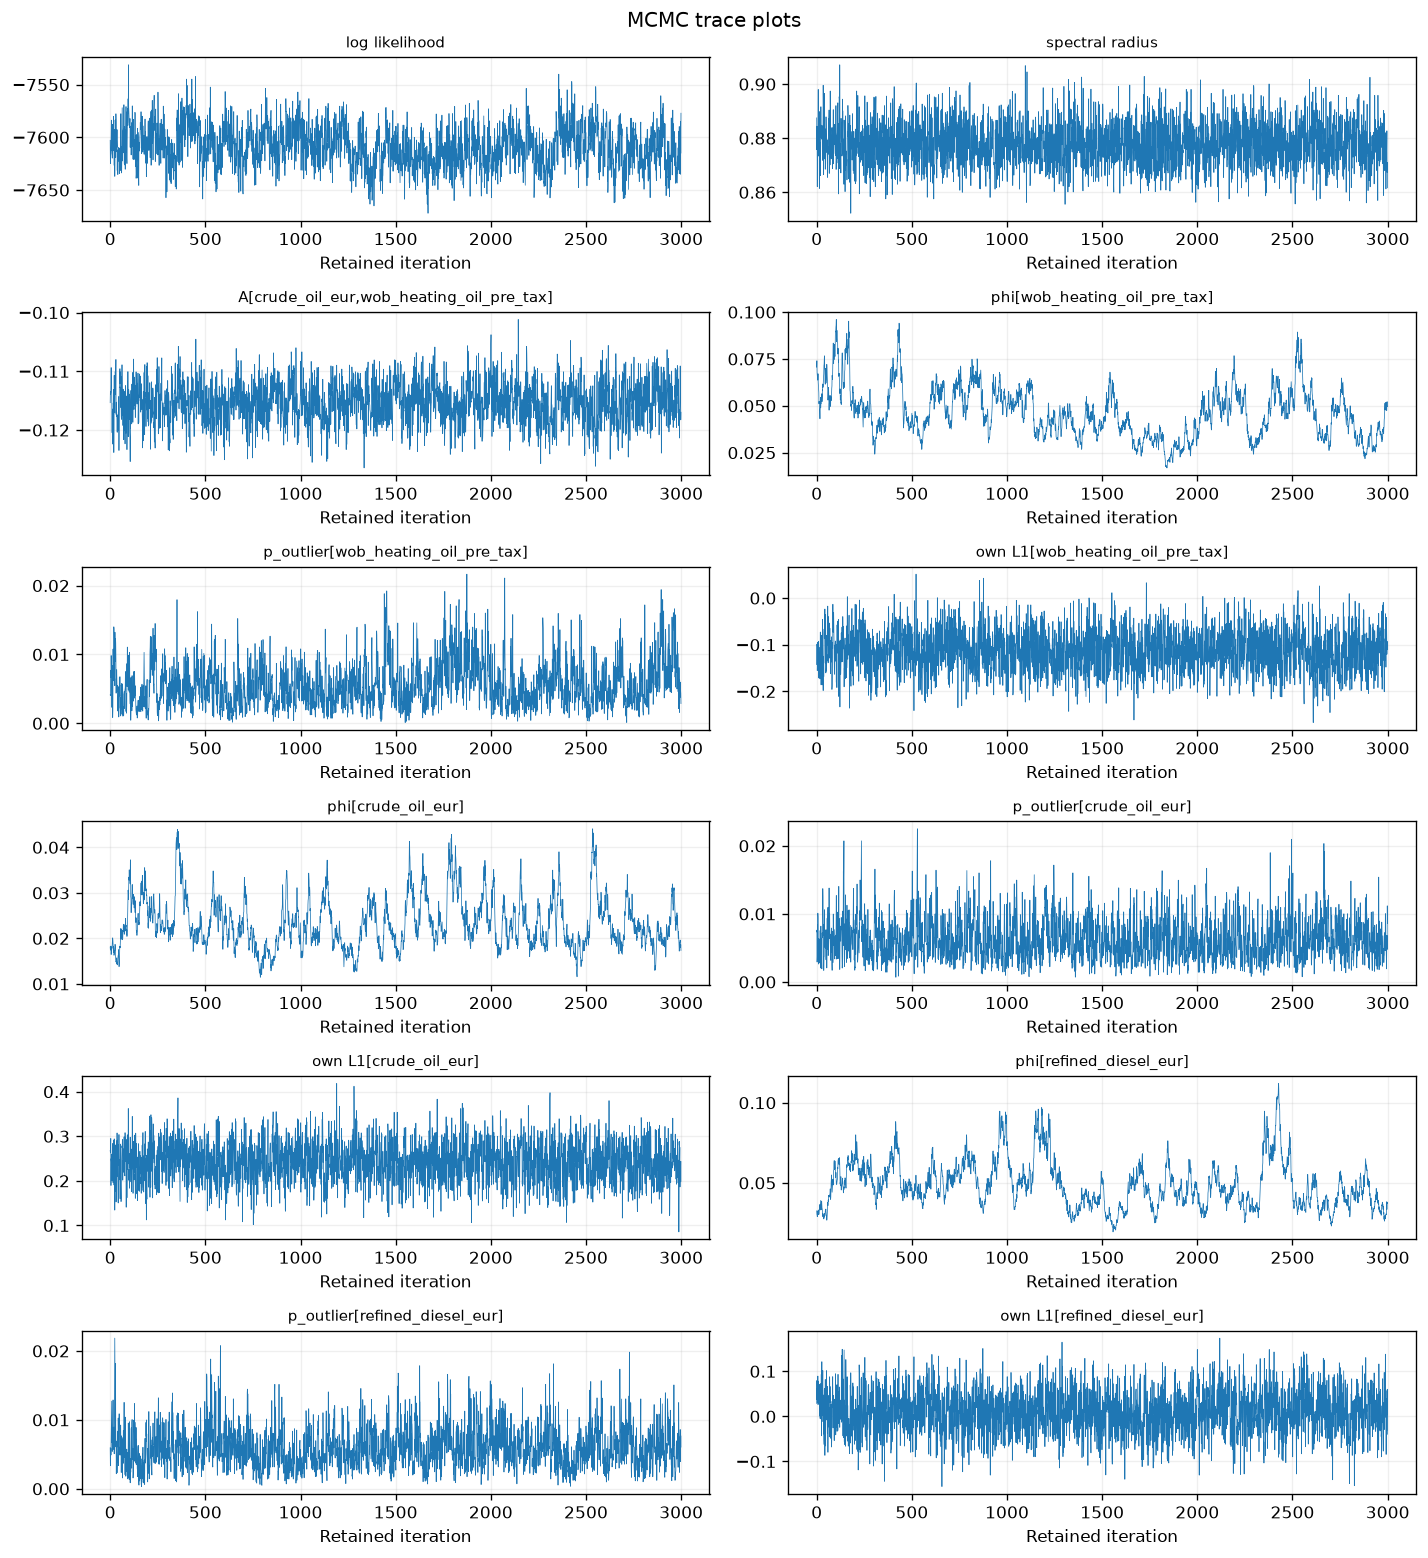

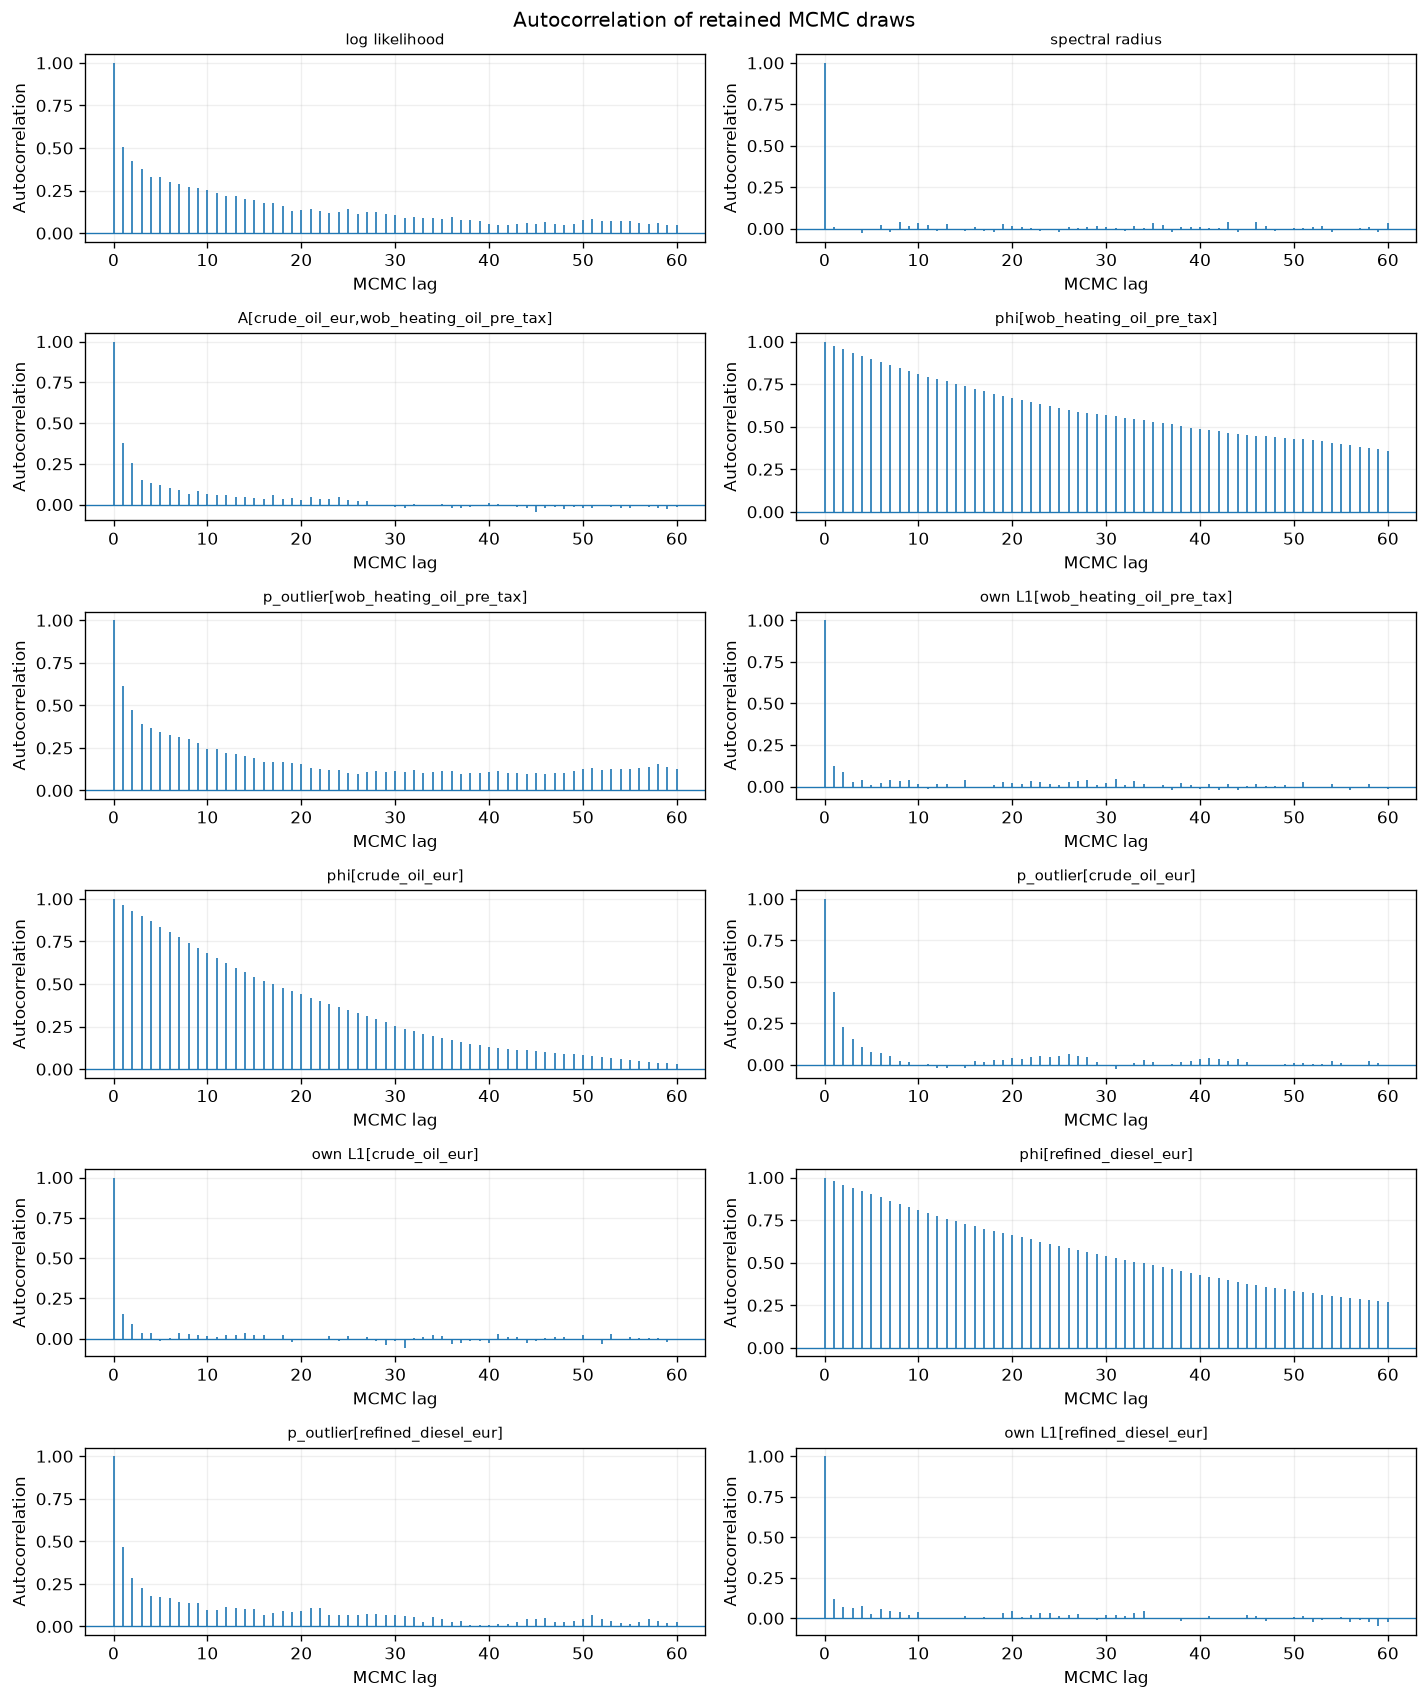

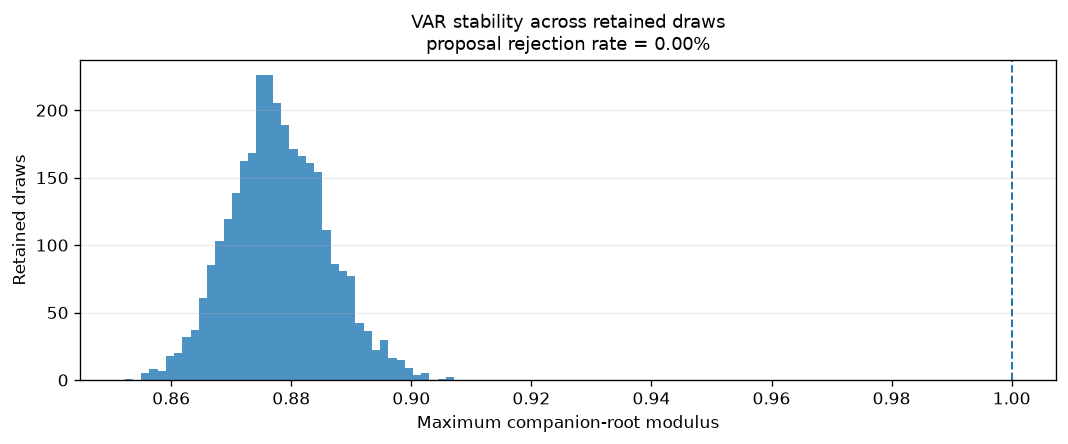

In [7]:
display(style_numeric_table(
    mcmc_diagnostics(result),
    caption="MCMC diagnostics",
))
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_trace_grid(result)
plt.show()
plot_chain_acf_grid(result, nlags=60)
plt.show()
plot_spectral_radius(result)
plt.show()

,wob_heating_oil_pre_tax,crude_oil_eur,refined_diesel_eur
date,,,
2026-03-09,0.64,0.27,0.02
2022-03-14,0.43,1.00,0.01
2019-05-06,0.31,6.00 × 10⁻³,0.68
2022-03-07,0.21,6.00 × 10⁻³,2.67 × 10⁻³
2022-03-21,0.20,0.12,0.82
2026-04-06,0.12,0.25,2.00 × 10⁻³
2025-06-23,0.10,0.02,1.00 × 10⁻³
2019-06-10,0.09,1.67 × 10⁻³,1.33 × 10⁻³
2020-12-21,0.07,0.04,0.09


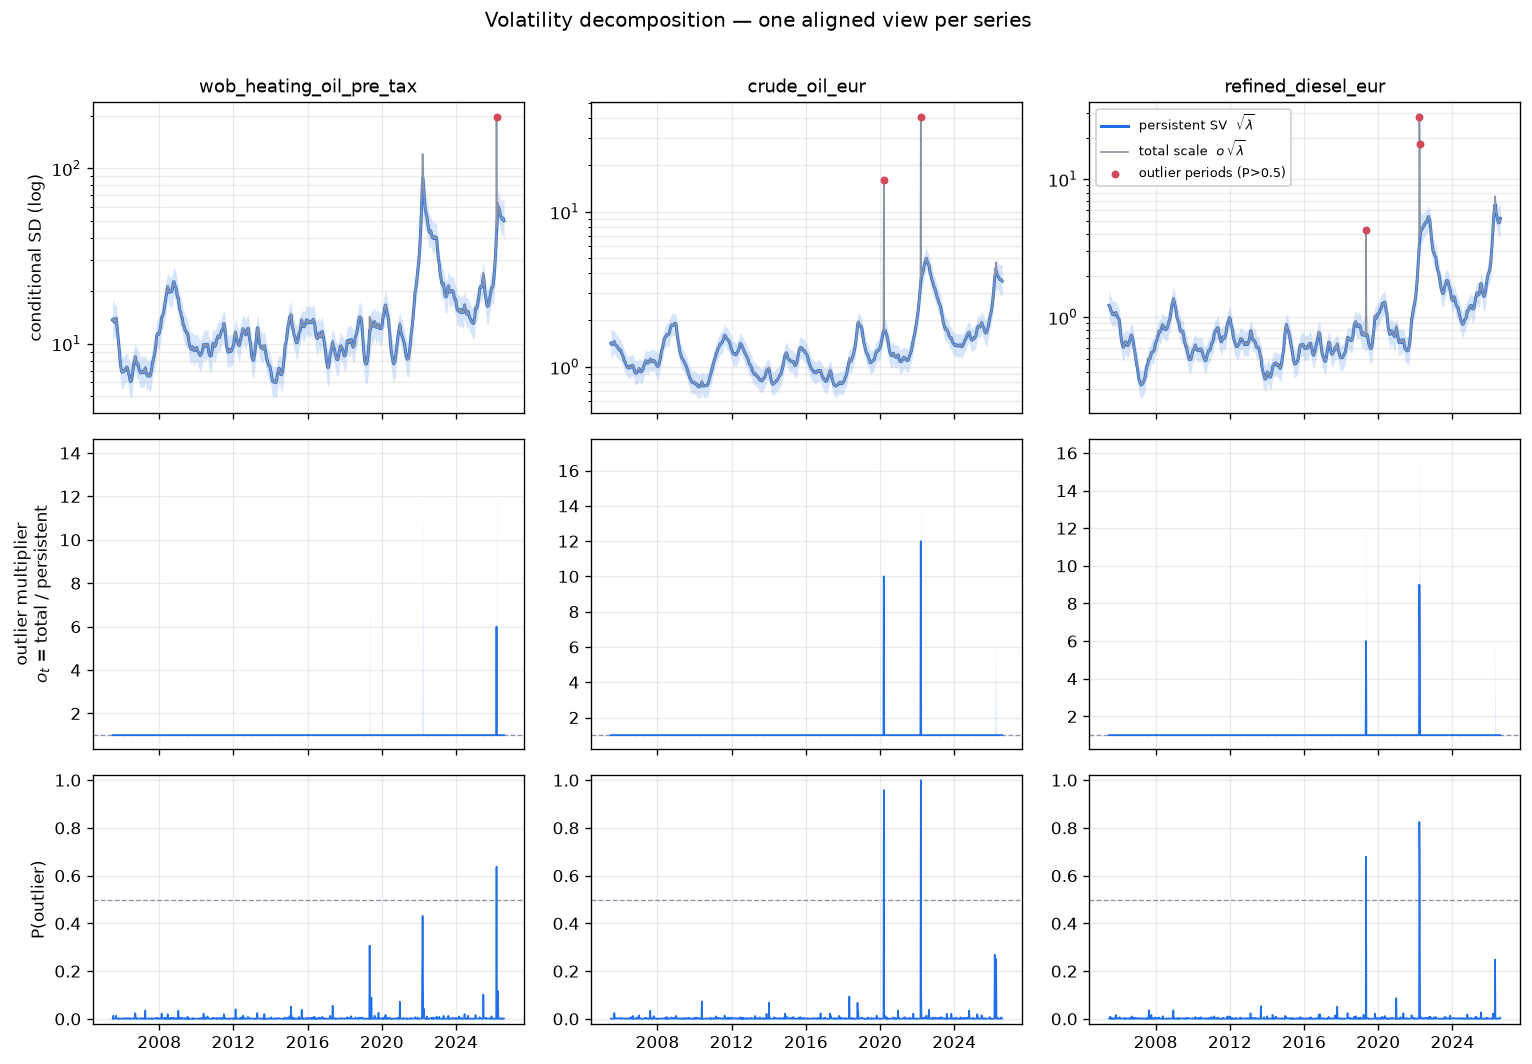

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
wob_heating_oil_pre_tax,-5.17 × 10⁻³,0.97,0.09,0.04,-3.30 × 10⁻³,3.58
crude_oil_eur,-9.46 × 10⁻³,0.97,-0.22,2.90 × 10⁻³,0.02,3.22
refined_diesel_eur,2.89 × 10⁻³,0.95,-0.09,-0.25,-0.01,3.15


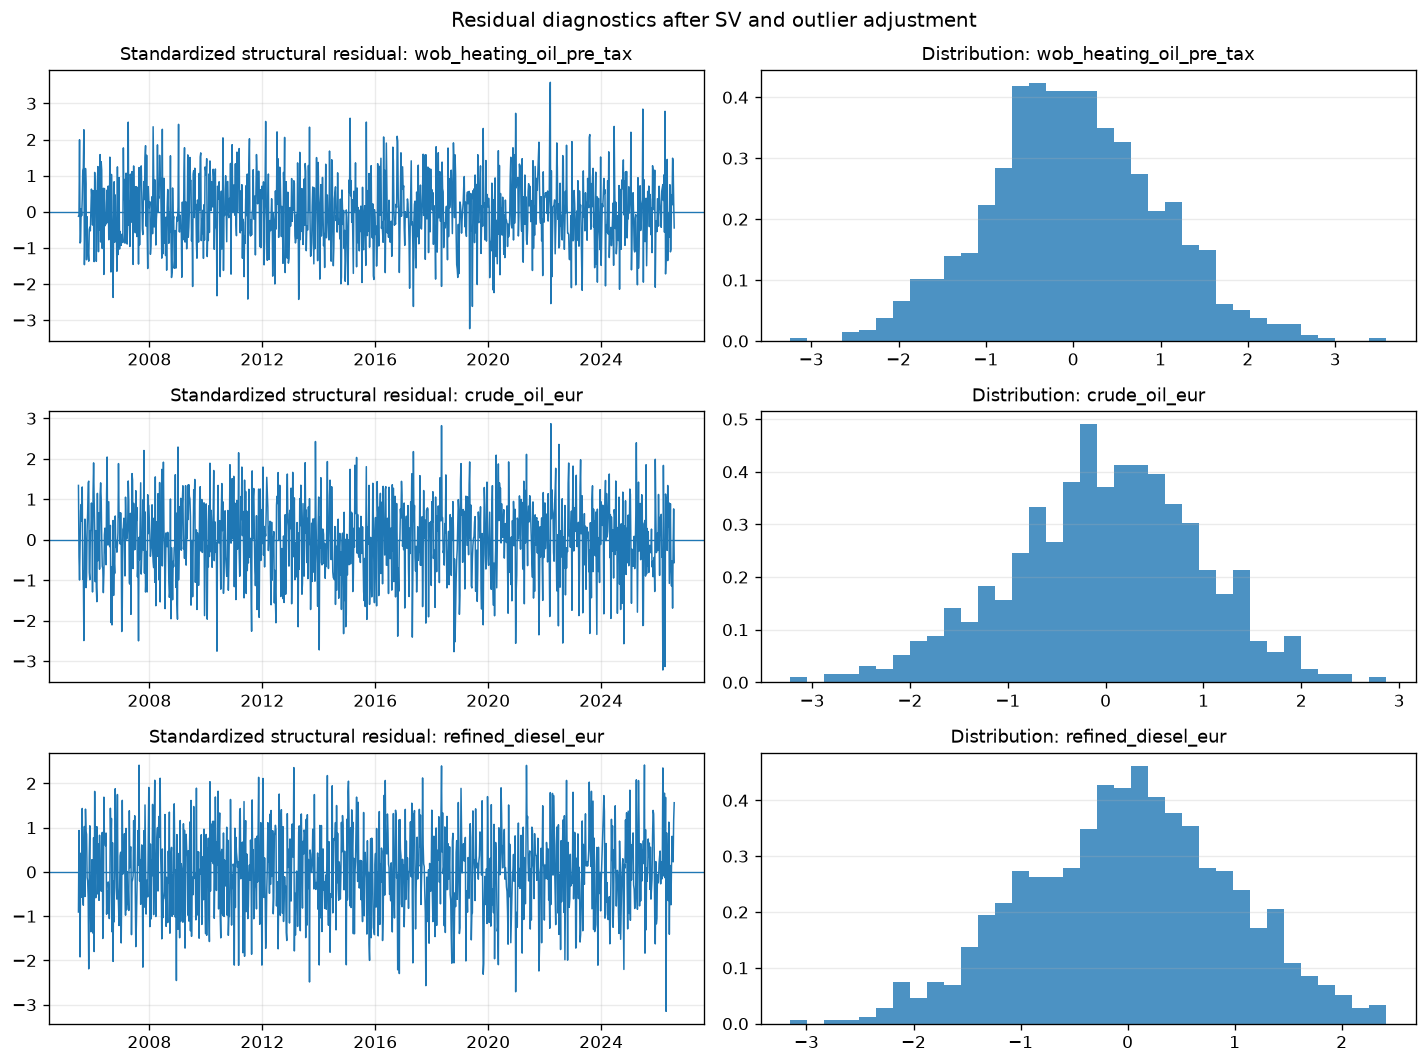

In [8]:
outlier_probability = posterior_outlier_probability(result)
display(style_numeric_table(
    outlier_probability.sort_values(TARGET, ascending=False).head(15),
    caption="Largest posterior outlier probabilities",
))
plot_volatility_decomposition(result)
plt.show()

display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

,observed,replicated_median,replicated_q05,replicated_q95
wob_heating_oil_pre_tax: mean,0.51,0.37,-1.44,2.38
wob_heating_oil_pre_tax: sd,23.73,23.90,19.58,45.85
wob_heating_oil_pre_tax: maximum_absolute,345.27,299.80,141.08,1180.44
crude_oil_eur: mean,0.03,0.06,-0.16,0.35
crude_oil_eur: sd,2.47,3.67,2.86,5.83
crude_oil_eur: maximum_absolute,17.23,55.74,21.17,151.01
refined_diesel_eur: mean,0.08,0.05,-0.20,0.36
refined_diesel_eur: sd,4.16,4.55,3.64,7.56
refined_diesel_eur: maximum_absolute,48.32,72.42,27.34,176.65


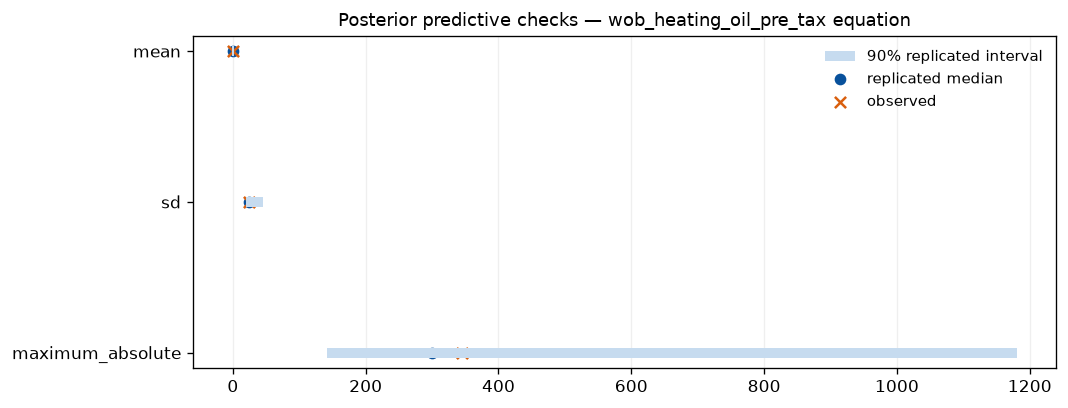

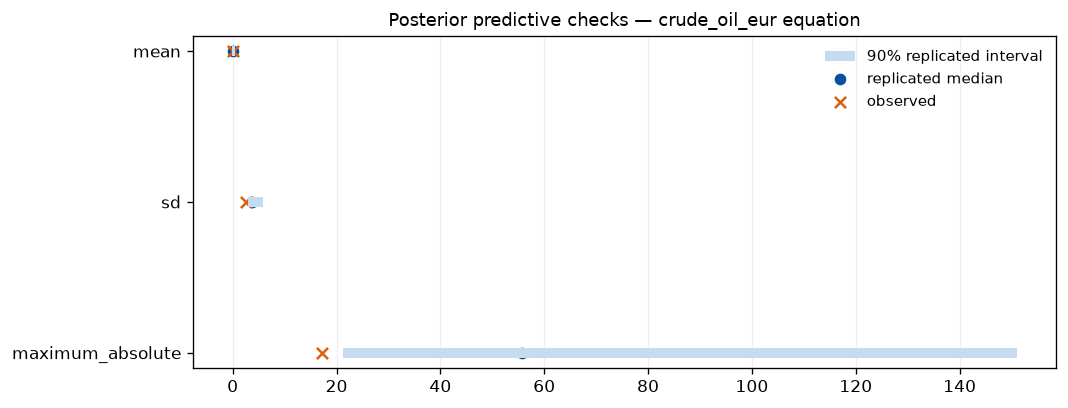

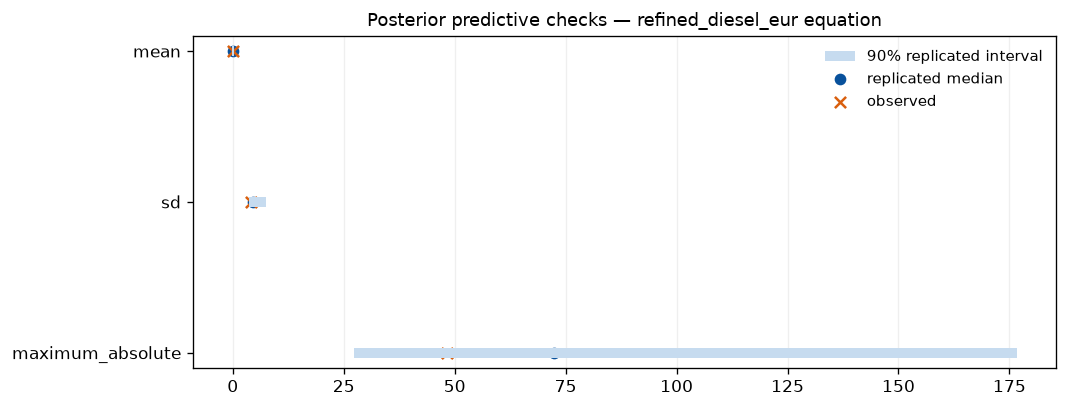

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
wob_heating_oil_pre_tax,-6.66,4.90 × 10⁻⁹,18.00,0.06,0.10,2.00,1107.00
crude_oil_eur,-10.02,1.69 × 10⁻¹⁷,12.00,0.05,0.10,5.00,1113.00
refined_diesel_eur,-7.48,4.71 × 10⁻¹¹,17.00,0.07,0.10,1.00,1108.00


In [9]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=PPC_DRAWS,
    seed=456,
)
display(style_numeric_table(
    ppc_summary,
    caption="Posterior predictive checks",
))
for equation in VARIABLES:
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

completed_changes = posterior_completed_differences(result, statistic="median")
display(style_numeric_table(
    stationarity_tests(completed_changes),
    caption="Stationarity tests on posterior-median completed weekly changes",
))

if "missing_level_draws" in result and result["missing_level_draws"].shape[1]:
    q = np.percentile(result["missing_level_draws"], [5, 16, 50, 84, 95], axis=0)
    positions = result["missing_level_positions"]
    imputed_summary = pd.DataFrame({
        "date": [item[0] for item in positions],
        "variable": [item[1] for item in positions],
        "q05": q[0],
        "q16": q[1],
        "median": q[2],
        "q84": q[3],
        "q95": q[4],
        "posterior_sd": np.std(result["missing_level_draws"], axis=0, ddof=1),
    }).set_index(["date", "variable"])
    display(style_numeric_table(
        imputed_summary,
        caption="Posterior draws for internally missing weekly levels",
    ))

## 6. Ragged-edge nowcast and weekly forecast


,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-08-10,nowcast,—,910.08,929.19,954.03,978.80,994.06


,weeks_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 week,1.00,2026-08-17,822.82,875.85,940.60,995.40,1041.03
4 weeks,4.00,2026-09-07,708.72,820.32,942.79,1085.03,1193.02
13 weeks,13.00,2026-11-09,381.40,677.62,946.88,1200.06,1453.70
26 weeks,26.00,2027-02-08,168.65,541.14,957.59,1338.65,1749.97


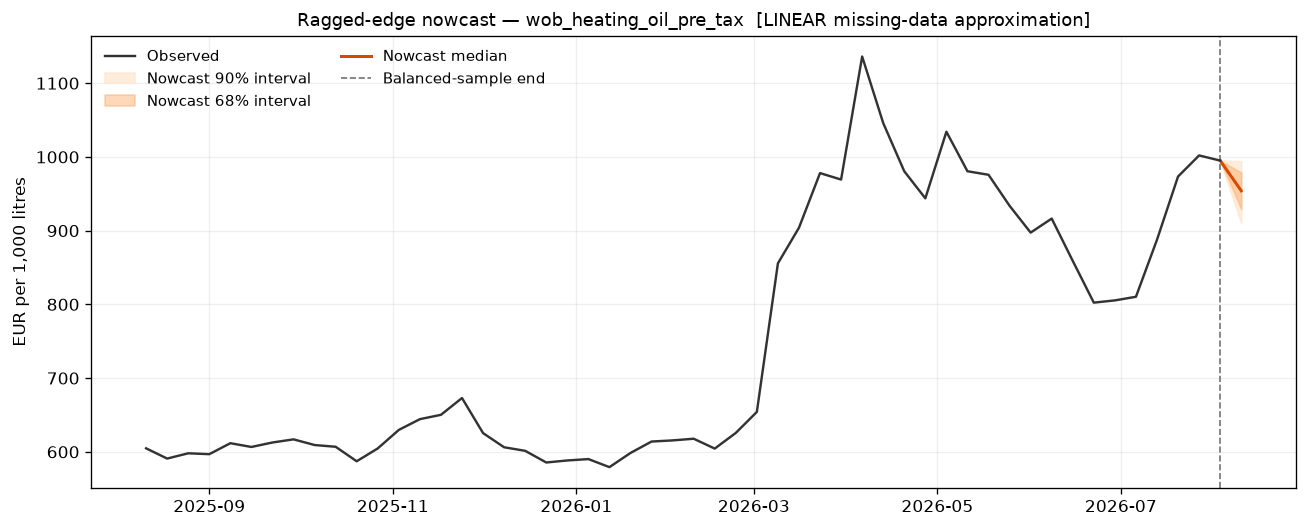

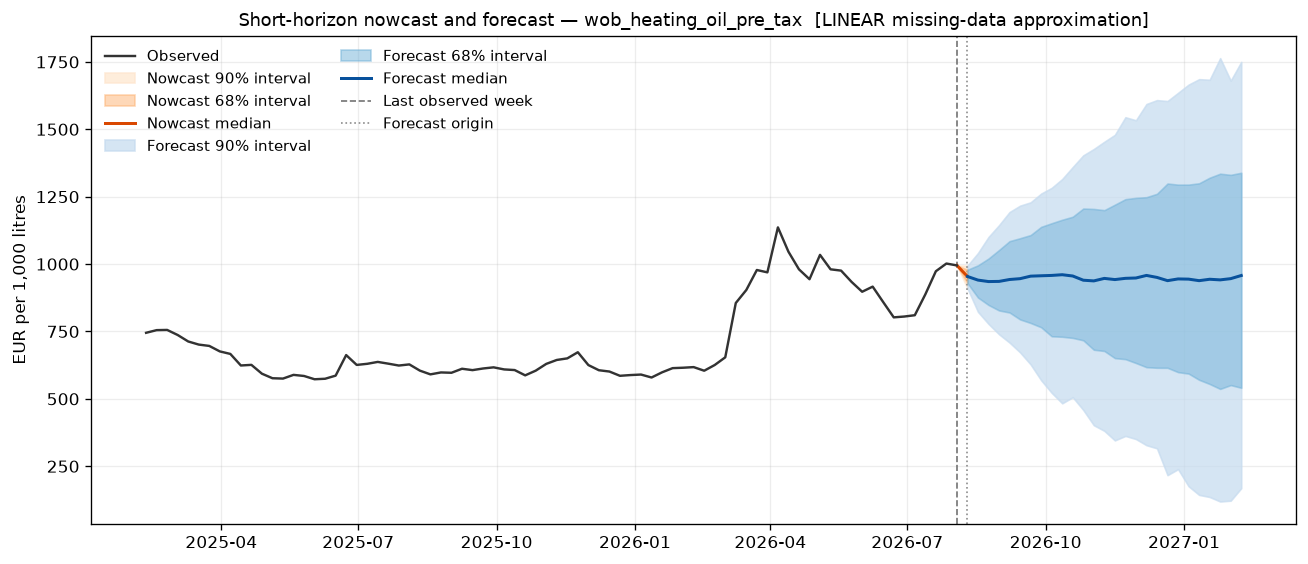

Saved unconditional forecast store: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\results\liquid_fuels\20260808\ef7625d8797235b448bb1da7f0db677cb016a0a326f4275086f8d3ef745042f8\forecasts\unconditional


In [10]:
forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=SIMULATE_FUTURE_OUTLIERS,
    seed=123,
)

display(style_numeric_table(
    nowcast_summary_table(
        forecast_unconditional,
        observed_levels=levels,
        variable=TARGET,
    ),
    caption="Ragged-edge liquid fuels nowcast",
))
display(style_numeric_table(
    weekly_forecast_horizon_table(
        forecast_unconditional,
        TARGET,
        horizons=(1, 4, 13, 26),
    ),
    caption="Weekly liquid fuels pre-tax forecast",
))

plot_nowcast_fan(
    forecast_unconditional,
    levels,
    TARGET,
    last_obs=52,
    ylabel=UNITS[TARGET],
)
plt.show()
plot_short_forecast_fan(
    forecast_unconditional,
    levels,
    TARGET,
    last_obs=78,
    ylabel=UNITS[TARGET],
)
plt.show()

if SAVE_FORECASTS:
    saved_forecast_paths = save_energy_bvar_forecast_for_result(
        forecast_unconditional,
        result,
        RESULTS_ROOT,
        "unconditional",
    )
    print(f"Saved unconditional forecast store: {saved_forecast_paths['directory']}")


## 7. Conditional commodity-price scenarios


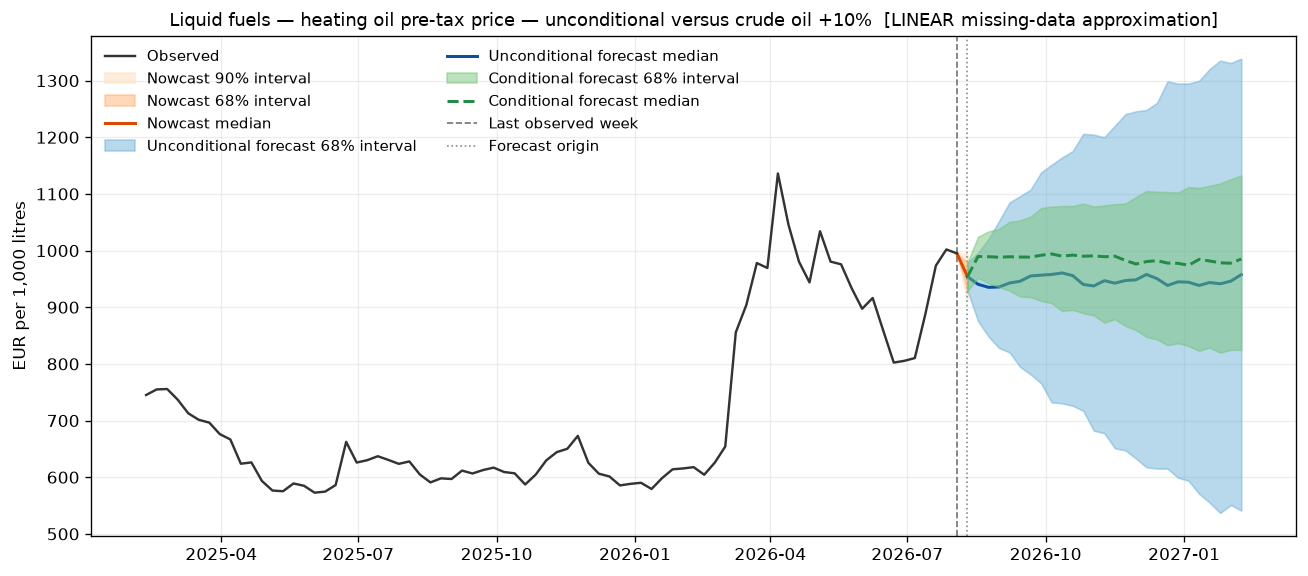

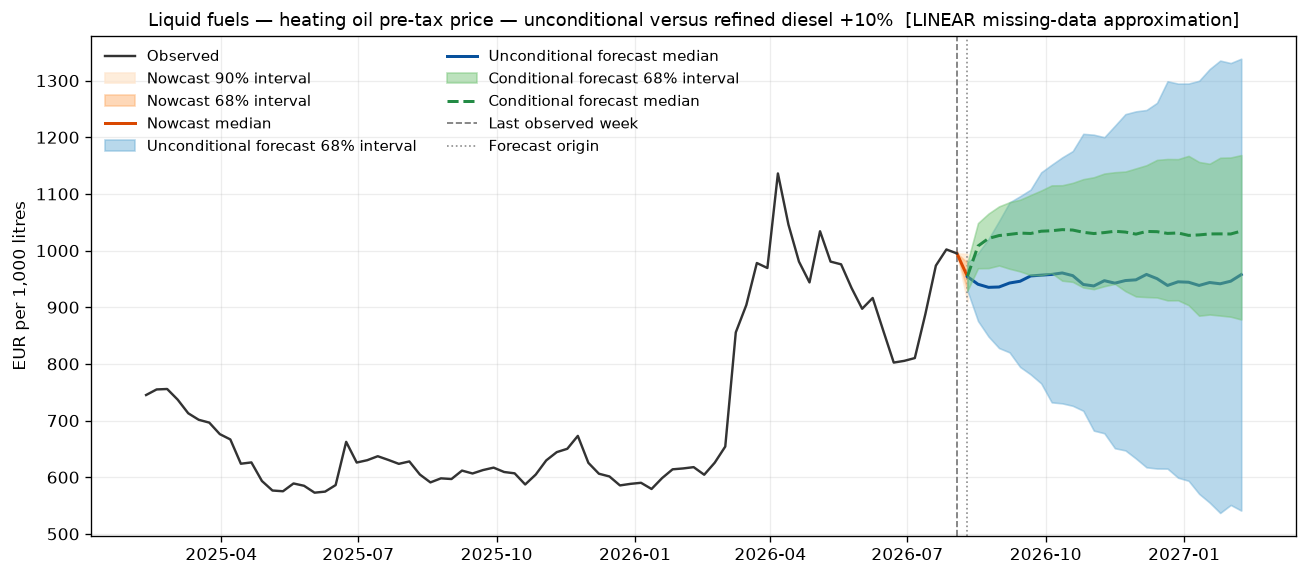

In [11]:
last_crude = float(levels["crude_oil_eur"].dropna().iloc[-1])
last_refined = float(levels["refined_diesel_eur"].dropna().iloc[-1])
crude_up_10 = np.full(FORECAST_H, 1.10 * last_crude)
refined_up_10 = np.full(FORECAST_H, 1.10 * last_refined)

forecast_crude_up_10 = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    level_conditions={"crude_oil_eur": crude_up_10},
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=SIMULATE_FUTURE_OUTLIERS,
    seed=123,
)
forecast_refined_up_10 = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    level_conditions={"refined_diesel_eur": refined_up_10},
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=SIMULATE_FUTURE_OUTLIERS,
    seed=123,
)

plot_forecast_comparison(
    forecast_unconditional,
    forecast_crude_up_10,
    levels,
    TARGET,
    last_obs=78,
    title="Liquid fuels — heating oil pre-tax price — unconditional versus crude oil +10%",
    ylabel=UNITS[TARGET],
)
plt.show()
plot_forecast_comparison(
    forecast_unconditional,
    forecast_refined_up_10,
    levels,
    TARGET,
    last_obs=78,
    title="Liquid fuels — heating oil pre-tax price — unconditional versus refined diesel +10%",
    ylabel=UNITS[TARGET],
)
plt.show()

## 8. Tax assumptions and inflation impact

The BVAR forecasts the **pre-tax** weekly liquid-fuels price. Excise and VAT are re-attributed **ex post**:

$$
P_t^{after\ tax}=\left(P_t^{pre\ tax}+EXC_t\right)\left(1+\frac{VAT_t}{100}\right).
$$

The historical WOB VAT and excise observations are already at the weekly model frequency. The first figure therefore shows the observed weekly tax history directly, followed by the paper baseline (latest value carried forward) and the alternative scenario. The scenario line is omitted for an instrument that does not differ from baseline.


### 8.1 Baseline tax reconstruction


In [ ]:
tax_context = load_weekly_tax_context(COMPONENT_DATASET, model=MODEL)
taxed_forecast = reattribute_weekly_taxes(
    forecast_unconditional,
    tax_context,
)

tax_summary = pd.Series({
    "WOB source": str(tax_context["wob_path"]),
    "WOB prefix": tax_context["wob_prefix"],
    "maximum historical tax-identity error": tax_context["max_tax_identity_error"],
    "forecast excise": taxed_forecast["excise"][-1],
    "forecast VAT percent": taxed_forecast["vat_percent"][-1],
    "excise unit": tax_context.get("excise_unit"),
    "tax assumption": taxed_forecast["tax_assumption"],
})
display(style_numeric_table(
    tax_summary.to_frame("value"),
    caption="Tax re-attribution inputs",
))

# Weekly post-tax prices, aggregated to monthly means for the consumer-price view.
monthly_after_tax_paths, monthly_after_tax_dates = weekly_paths_to_monthly_mean(
    taxed_forecast["after_tax_paths"],
    taxed_forecast["path_dates"],
)
monthly_q = np.percentile(monthly_after_tax_paths, [5, 16, 50, 84, 95], axis=0)
monthly_after_tax_table = pd.DataFrame({
    "q05": monthly_q[0],
    "q16": monthly_q[1],
    "median": monthly_q[2],
    "q84": monthly_q[3],
    "q95": monthly_q[4],
}, index=monthly_after_tax_dates)
display(style_numeric_table(
    monthly_after_tax_table,
    caption="Monthly mean liquid-fuels price after tax",
))

fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.fill_between(monthly_after_tax_dates, monthly_q[0], monthly_q[4], alpha=0.20, label="90% interval")
ax.fill_between(monthly_after_tax_dates, monthly_q[1], monthly_q[3], alpha=0.35, label="68% interval")
ax.plot(monthly_after_tax_dates, monthly_q[2], linewidth=1.8, label="Median")
ax.set_title("Monthly mean liquid-fuels consumer price after tax")
ax.set_ylabel("EUR per 1,000 litres")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Baseline accounting wedge, retained as a numerical diagnostic.
display(style_numeric_table(
    tax_inflation_spread_table(taxed_forecast),
    caption="Baseline tax wedge — post-tax minus pre-tax 52-week inflation (pp)",
))


KeyError: 'The v9 European_Commission workbook sheet contains with-tax and no-tax prices but not the VAT/IDT columns required for separate tax scenarios. Add the corresponding wob_*_vat and wob_*_idt series to that sheet (or pass an explicit legacy WOB tax CSV). WTAX and NTAX alone cannot uniquely identify VAT and excise.'

: 

### 8.2 Historical taxes and future assumptions

The chart is windowed to the policy-relevant history so the future step remains visible. VAT is in **percent**; the scenario change is measured in **percentage points**. Excise remains in EUR per 1,000 litres.


In [ ]:
# Illustrative sensitivity: +1 percentage point of VAT from the first forecast week.
TAX_SCENARIO_START = pd.Timestamp(forecast_unconditional["future_dates"][0])
baseline_vat_at_start = float(
    taxed_forecast["baseline_vat_percent_path"].loc[TAX_SCENARIO_START]
)
TAX_SCENARIO = {
    "start_date": TAX_SCENARIO_START,
    "vat_percent": baseline_vat_at_start + 1.0,
}
# To condition excise too:
# TAX_SCENARIO["excise"] = <level in tax_context["excise_unit"]>
# TAX_SCENARIO["excise_unit"] = tax_context["excise_unit"]

taxed_forecast_scenario = reattribute_weekly_taxes(
    forecast_unconditional,
    tax_context,
    tax_scenario=TAX_SCENARIO,
)

display(style_numeric_table(
    taxed_forecast_scenario["tax_path"].reindex(taxed_forecast_scenario["future_dates"]),
    caption="Future tax path — baseline versus scenario",
))

plot_tax_assumptions(
    tax_context,
    taxed_forecast_scenario,
    component_label="liquid fuels",
    lookback_years=5,
)
plt.show()


### 8.3 Full-inflation forecast: baseline versus tax scenario

This figure compares the **full consumer-price inflation forecast** under the paper baseline tax assumption with the alternative tax scenario.

Both paths use the **same posterior BVAR pre-tax draws**. The only difference is the ex-post VAT/excise path. The shaded areas are 68% posterior intervals. This view answers the forecasting question — *what does full inflation look like under the alternative tax assumption?* — while Section 8.4 isolates the scenario effect draw by draw.

In [ ]:
plot_tax_scenario_impact(
    taxed_forecast_scenario,
    component_label="liquid fuels",
    show_intervals=True,
    impact_annotations="last",
)
plt.show()


### 8.4 Price-level and inflation effects

The left panel reports the relative consumer-price level effect of the tax scenario. The right panel reports the scenario-minus-baseline effect on 52-week inflation. A permanent VAT step leaves a persistent level effect but only a temporary inflation base effect.


In [ ]:
display(style_numeric_table(
    tax_scenario_effect_summary_table(taxed_forecast_scenario),
    caption="Tax-scenario effect — price level (%) and 52-week inflation (pp)",
))

plot_tax_level_and_inflation_impact(
    taxed_forecast_scenario,
    component_label="liquid fuels",
    lookback_years=1,
)
plt.show()

np.testing.assert_allclose(
    taxed_forecast_scenario["pre_tax_inflation_paths"],
    taxed_forecast["pre_tax_inflation_paths"],
    rtol=0.0,
    atol=1e-12,
)

dates = pd.DatetimeIndex(taxed_forecast_scenario["path_dates"])
before = dates < pd.Timestamp(TAX_SCENARIO_START)
np.testing.assert_allclose(
    taxed_forecast_scenario["post_tax_inflation_paths"][:, before],
    taxed_forecast_scenario["baseline_post_tax_inflation_paths"][:, before],
    rtol=0.0,
    atol=1e-12,
)

print("PASS — tax scenario changes only the ex-post tax layer and only from its start date")


## 9. Structural analysis


In [ ]:
# Structural objects can be large. Use a reproducible posterior subset for plots.
structural_count = min(STRUCTURAL_DRAWS, result["n_draws"])
structural_index = np.linspace(
    0,
    result["n_draws"] - 1,
    structural_count,
    dtype=int,
)
structural_result = dict(result)
for key in (
    "B", "A", "log_variance", "phi", "outlier_scales",
    "outlier_indicators", "outlier_probabilities",
    "posterior_outlier_probability_draws", "spectral_radius", "log_likelihood",
    "completed_differences_draws", "missing_level_draws",
    "last_companion_state_draws",
):
    if key in result:
        structural_result[key] = np.asarray(result[key])[structural_index]
structural_result["n_draws"] = structural_count

irf = impulse_responses(
    structural_result,
    identification="recursive",
    horizon=24,
    shock_unit="structural_std",
)
plot_impulse_responses(irf, cumulative=True, units=UNITS)
plt.show()

fevd = forecast_error_variance_decomposition(
    structural_result,
    identification="recursive",
    horizon=24,
)
plot_fevd(fevd, responses=[TARGET])
plt.show()

hd = historical_decomposition(
    structural_result,
    identification="recursive",
    split_outlier_amplification=True,
)
print(f"Maximum historical-decomposition reconstruction error: {hd['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd,
    response=TARGET,
    last_obs=156,
    unit=UNITS[TARGET],
)
plt.show()

## 10. Forecast validation tests


In [ ]:
base_level = np.asarray(result["prep"]["level_at_balanced_end"], dtype=float)
reconstructed_levels = (
    base_level[None, None, :]
    + np.cumsum(forecast_unconditional["diff_paths"], axis=1)
)
cumulative_error = float(np.max(np.abs(
    reconstructed_levels - forecast_unconditional["level_paths"]
)))

observed = levels.reindex(
    forecast_unconditional["path_dates"]
).to_numpy(dtype=float)
observation_errors = []
for j, variable in enumerate(VARIABLES):
    mask = np.isfinite(observed[:, j])
    if mask.any():
        observation_errors.append(float(np.max(np.abs(
            forecast_unconditional["level_paths"][:, mask, j]
            - observed[None, mask, j]
        ))))
observed_error = max(observation_errors, default=0.0)

crude_condition_error = float(np.max(np.abs(
    forecast_crude_up_10["future_level_paths"][:, :, VARIABLES.index("crude_oil_eur")]
    - crude_up_10[None, :]
)))
refined_condition_error = float(np.max(np.abs(
    forecast_refined_up_10["future_level_paths"][:, :, VARIABLES.index("refined_diesel_eur")]
    - refined_up_10[None, :]
)))

in_sample_observed_error = 0.0
if "completed_differences_draws" in result:
    completed = np.asarray(result["completed_differences_draws"], dtype=float)
    path_diffs = completed[:, P:, :]
    anchor = np.asarray(result["prep"]["augmentation_anchor_level"], dtype=float)
    reconstructed_in_sample = anchor[None, None, :] + np.cumsum(path_diffs, axis=1)
    observed_in_sample = result["prep"]["estimation_levels"].to_numpy(dtype=float)
    if np.isfinite(observed_in_sample).any():
        in_sample_observed_error = float(np.nanmax(np.abs(
            reconstructed_in_sample - observed_in_sample[None, :, :]
        )))

validation = pd.Series({
    "missing-data method": result["metadata"]["missing_data_method"],
    "missing treatment exact": result["metadata"]["missing_treatment_exact"],
    "interpolated level cells": result["metadata"]["interpolated_level_cells"],
    "metadata frequency is weekly": result["metadata"]["frequency"] == "weekly",
    "DK interior data augmentation active": result["metadata"].get("requires_data_augmentation", False),
    "all processed dates are Mondays": bool((levels.index.dayofweek == 0).all()),
    "all future dates are Mondays": bool((forecast_unconditional["future_dates"].dayofweek == 0).all()),
    "forecast cumulative level identity error": cumulative_error,
    "maximum released ragged-level error": observed_error,
    "maximum released in-sample level error": in_sample_observed_error,
    "crude +10% condition error": crude_condition_error,
    "refined diesel +10% condition error": refined_condition_error,
    "retained unstable share": float(stability_diagnostics(result)["retained_unstable_share"]),
})
display(style_numeric_table(
    validation.to_frame("value"),
    caption="Weekly DK data-augmentation and forecast validation",
))

assert result["metadata"]["frequency"] == "weekly"
assert result["metadata"].get("requires_data_augmentation", False)
assert (levels.index.dayofweek == 0).all()
assert (forecast_unconditional["future_dates"].dayofweek == 0).all()
assert cumulative_error < 1e-8
assert observed_error < 1e-8
assert in_sample_observed_error < 1e-8
assert crude_condition_error < 1e-8
assert refined_condition_error < 1e-8
assert stability_diagnostics(result)["retained_unstable_share"] == 0.0

print("All weekly calendar, interior-DK, ragged-edge and conditioning checks passed.")